<br><br><br>
<h2><font size=6>Práctica 1</font></h2>



<h1><font size=7>Árboles de decisión</font></h1>

<br>
<div style="text-align: right">
<font size=4>Pablo Torrijos Arenas (Pablo.Torrijos@uclm.es)</font><br>
<font size=4>José Miguel Puerta Callejón (Jose.Puerta@uclm.es)</font><br>
</div>

**<font color="#B30033" size=5>Estudiantes: </font>** 

* Guillermo Morcillo Conchán
* David Gómez Aniorte

---

# 1. Introducción

El objetivo de esta práctica es estudiar el uso de árboles de decisión para la predicción del ingreso de distintas personas en función de sus datos censales. Para ello usaremos la base de datos [`adult`](https://archive.ics.uci.edu/dataset/2/adult), también conocida como [`census-income`](https://archive.ics.uci.edu/dataset/20/census+income). 

En esta práctica comenzaremos explorando `scikit-learn` y su implementación de los árboles de decisión, realizando un estudio comparativo de los distintos hiperparámetros que ofrece. 

Posteriormente, se proporciona el esqueleto para la implementación del algoritmo C4.5 que usaremos como base para el resto de la práctica. A partir de ella, se pide:
- Capacidad de tratar con variables y discretas continuas.
- Implementar el error de clasificación, el índice GINI y la entropía condicional para el cálculo del error.
- Poda del árbol.
- Estudio del algoritmo implementado.

Baremo de puntuaciones:

| Tarea                     | Peso | 
|----------|----------|
| Estudio comparativo con `scikit-learn`      | 10%   |
| Variables discretas       | 15%   |
| Variables continuas       | 25%   |
| Implementación de las métricas           | 10%   |
| Poda del árbol            | 25%   |
| Estudio final del algoritmo implementado           | 15%   |



---

# 2. Carga del dataset

El dataset que usaremos trata de predecir si los ingresos son superiores o inferiores a 50K en base a una serie de variables. Para cargar los datos usaremos `pandas`, mientras que `numpy` será necesario para realizar diversas funciones a lo largo de la práctica.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
#



In [81]:
df = pd.read_csv('adult.csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## 2.1. Análisis exploratorio

Podemos ver información de las distintas variables con `df.info()`:

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Así, vemos como efectivamente tenemos tanto variables categóricas como numéricas. En principio parece estar todo correcto, sin valores perdidos, pero si observamos los valores únicos de cada variable:

In [83]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education-num        16
marital-status        7
occupation           15
relationship          6
race                  5
sex                   2
capital-gain        119
capital-loss         92
hours-per-week       94
native-country       42
income                2
dtype: int64

In [84]:
df.apply(lambda col: col.sort_values().unique())

age               [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...
workclass         [?, Federal-gov, Local-gov, Never-worked, Priv...
fnlwgt            [12285, 13769, 14878, 18827, 19214, 19302, 193...
education         [10th, 11th, 12th, 1st-4th, 5th-6th, 7th-8th, ...
education-num     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
marital-status    [Divorced, Married-AF-spouse, Married-civ-spou...
occupation        [?, Adm-clerical, Armed-Forces, Craft-repair, ...
relationship      [Husband, Not-in-family, Other-relative, Own-c...
race              [Amer-Indian-Eskimo, Asian-Pac-Islander, Black...
sex                                                  [Female, Male]
capital-gain      [0, 114, 401, 594, 914, 991, 1055, 1086, 1111,...
capital-loss      [0, 155, 213, 323, 419, 625, 653, 810, 880, 97...
hours-per-week    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
native-country    [?, Cambodia, Canada, China, Columbia, Cuba, D...
income                                          

Podemos ver cómo en `workclass`, `occupation` y `native-country` hay valores desconocidos representados por `?`. Vamos a ver cómo quedaría nuestro DataFrame si los reemplazamos por `NaN` para que `pandas` los reconozca como valores perdidos:

In [85]:
df.replace('?', np.nan).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Así, ahora podemos ver cómo la cuenta de valores no nulos ha cambiado. Por defecto, como las variables eran categóricas, estaba contando las `?` como una categoría más. 

Cuando conocemos la causa de los valores perdidos puede tener sentido dejarlos como una categoría más. Por ejemplo, suponed que estamos recogiendo datos de un radar en el que la velocidad máxima que puede medir son 200 km/h. Si un coche pasa a 215 km/h el radar nos daría un `?` en ese dato, pero si sabemos el motivo de estos valores perdidos, podríamos cambiar el nombre de esa categoría a `>200km/h`.

Ya que en esta práctica no vamos a introducir el manejo de los valores perdidos en nuestros árboles de decisión, y puesto que dichos valores solo aparecen en variables categóricas, por simplicidad vamos a dejar la base de datos tal cual está, contando a `?` como un valor categórico más. 

## 2.2. De `pandas` a `numpy`

A continuación vamos a transformar nuestros datos en arrays de `numpy` ya que los necesitaremos para trabajar con ellos posteriormente. `pandas` tiene muchas características muy útiles para hacer el análisis exploratorio y el preprocesamiento de los datos gracias a sus funciones de selección, agregación, agrupación... pero posteriormente todos los algoritmos de aprendizaje automático suelen trabajar con arrays de `numpy` dada su velocidad.

Vamos a empezar con los nombres de las variables. Por un lado vamos a guardar cuáles son nuestras variables predictoras y cuál nuestra variable objetivo.

In [86]:
features = df.columns
features

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [87]:
attributes = features[:-1]
target = features[-1]

print('Predictoras:',attributes)
print('Objetivo:',target)

Predictoras: Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')
Objetivo: income


Además, vamos a distinguir entre variables continuas (las que son de tipo `int64`) y discretas (de tipo `object`), ya que a la hora de hacer nuestros árboles de decisión habrá que tratarlas de forma distinta.

In [88]:
cont_atts = df.columns[df.dtypes == 'int64']
cont_atts = cont_atts.drop('fnlwgt')

disc_atts = df.columns[df.dtypes == 'object'] 
disc_atts = disc_atts.drop(target)

print('Continuas:',cont_atts)
print('Discretas:',disc_atts)

Continuas: Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Discretas: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


Finalmente, separamos el dataset en predictor y objetivo. Es convención en ciencia de datos usar $X$ para las variables predictoras e $y$ para la variable objetivo. La mayoría de los modelos se entrenan usando esas dos variables por separado.

In [89]:
X, y = df[attributes].to_numpy(), df[target].to_numpy()
X

array([[39, 'State-gov', 77516, ..., 0, 40, 'United-States'],
       [50, 'Self-emp-not-inc', 83311, ..., 0, 13, 'United-States'],
       [38, 'Private', 215646, ..., 0, 40, 'United-States'],
       ...,
       [58, 'Private', 151910, ..., 0, 40, 'United-States'],
       [22, 'Private', 201490, ..., 0, 20, 'United-States'],
       [52, 'Self-emp-inc', 287927, ..., 0, 40, 'United-States']],
      shape=(32561, 14), dtype=object)

In [90]:
y

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '>50K'],
      shape=(32561,), dtype=object)

## 2.3. Datos de test

Cuando nos enfrentamos a un problema de aprendizaje automático, es imprescindible que los datos de test que usemos para medir el rendimiento del modelo sean distintos a los datos con los que se entrena. En este caso, como los autores del conjunto de datos nos proporcionan un conjunto de datos separado para test, lo usaremos directamente. Si no, tendríamos que dividir el conjunto de datos original en dos partes, una para entrenar y otra para test.

**Nota:** En la práctica, es común dividir el conjunto de datos en tres partes: entrenamiento, validación y test. La validación se usa para ajustar los hiperparámetros del modelo, y el conjunto de test se usa para medir el rendimiento final del modelo. En este caso, como no vamos a ajustar hiperparámetros y por simplicidad, no usaremos conjunto de validación.

In [91]:
df_test = pd.read_csv('adult_test.csv')
df_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
16277,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
16278,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
16279,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [92]:
X_test, y_test = df_test[attributes].to_numpy(), df_test[target].to_numpy()
X_test

array([[25, 'Private', 226802, ..., 0, 40, 'United-States'],
       [38, 'Private', 89814, ..., 0, 50, 'United-States'],
       [28, 'Local-gov', 336951, ..., 0, 40, 'United-States'],
       ...,
       [38, 'Private', 374983, ..., 0, 50, 'United-States'],
       [44, 'Private', 83891, ..., 0, 40, 'United-States'],
       [35, 'Self-emp-inc', 182148, ..., 0, 60, 'United-States']],
      shape=(16281, 14), dtype=object)

In [93]:
y_test

array(['<=50K', '<=50K', '>50K', ..., '<=50K', '<=50K', '>50K'],
      shape=(16281,), dtype=object)

---

# 3. Árboles de decisión en `scikit-learn`



Para esta práctica vamos a utilizar el módulo [tree](http://scikit-learn.org/stable/modules/tree.html) de `scikit-learn`. Esta librería permite utilizar diversos algoritmos de _machine learning_ en Python, siendo los árboles de decisión uno de ellos. En particular, utilizaremos [`DecisionTreeClassifier`](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), la implementación de un árbol de decisión para problemas de clasificación de `scikit-learn`. 

La implementación que tiene `scikit-learn` de los árboles de decisión no es exactamente la del C4.5 si no que el algoritmo se llama CART. Existen algunas diferencias, pero la que más nos afectará es que los árboles generados son **binarios** y que no puede tratar variables discretas sin un procesado previo. 

Por tanto, para poder usar este algoritmo con nuestros datos tendremos que convertir las variables categóricas a numéricas. Para ello, podríamos usar el método [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) de `scikit-learn`, pero usaremos el método `df.get_dummies()` que nos proporciona directamente `pandas` ya que es similar y más simple de aplicar. Este método básicamente crea una nueva columna por cada valor posible de cada variable categórica y pone un 1 en la columna correspondiente al valor de la fila y un 0 en las demás, pasando así de variables categóricas a numéricas:

![OneHotEnconding](./imagenes/get_dummies.png)

## 3.1. Transformación de los datos para usarlos con `DecisionTreeClassifier`

Vamos a transformar nuestros datos:

In [94]:
df_ohe = pd.get_dummies(df.drop(target, axis=1))
df_ohe

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32557,40,154374,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32558,58,151910,9,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32559,22,201490,9,0,0,20,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [95]:
df_test_ohe = pd.get_dummies(df_test.drop(target, axis=1))
df_test_ohe

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,103497,10,0,0,30,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,215419,13,0,0,36,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16277,64,321403,9,0,0,40,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16278,38,374983,13,0,0,50,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16279,44,83891,13,5455,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [96]:
set(df_ohe.columns) - set(df_test_ohe.columns)

{'native-country_Holand-Netherlands'}

Como en el test nos falta una columna (ya que `Holand-Netherlands` no aparece en la variable `native-country`), tenemos que añadirla para no tener problemas posteriores.

In [97]:
df_ohe, df_test_ohe = df_ohe.align(df_test_ohe, join='outer', axis=1, fill_value=0)
df_test_ohe

,age,capital-gain,capital-loss,education-num,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,...,sex_Male,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,25,0,0,7,False,True,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,38,0,0,9,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
2,28,0,0,12,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
3,44,7688,0,10,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4,18,0,0,10,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,39,0,0,13,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
16277,64,0,0,9,False,False,False,False,False,False,...,True,True,False,False,False,False,False,False,False,False
16278,38,0,0,13,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
16279,44,5455,0,13,False,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


In [98]:
X_ohe, X_test_ohe = df_ohe.to_numpy(), df_test_ohe.to_numpy()
X_ohe

array([[39, 2174, 0, ..., False, True, False],
       [50, 0, 0, ..., True, False, False],
       [38, 0, 0, ..., False, False, False],
       ...,
       [58, 0, 0, ..., False, False, False],
       [22, 0, 0, ..., False, False, False],
       [52, 15024, 0, ..., False, False, False]],
      shape=(32561, 108), dtype=object)

## 3.2. Estudio de `DecisionTreeClassifier`

El `DecisionTreeClassifier` cuenta con una serie de hiperparámetros con los que podemos ajustar su funcionamiento. Algunos de los que nos pueden ser más útiles son:
* `criterion`: Especifica la función para medir la calidad de una partición. Puede ser `gini` o `entropy`.
* `max_depth`: Profundidad máxima del árbol. 
* `min_samples_leaf`: Mínimo número de ejemplos que debe haber en una hoja.

En la documentación de `scikit-learn` está toda la información sobre los hiperparámetros del algoritmo. Por lo que si se desea se puede extender el estudio probando más configuraciones. Para ello se debe especificar que hiperparámetros extra se han seleccionado, para que sirven y como afectan al árbol y justificar dicho comportamiento con los resultados obtenidos.

In [99]:
from sklearn import tree 
from sklearn.tree import DecisionTreeClassifier

In [100]:
criterion = 'entropy'
max_depth = 2 #Bajo 2-4, medio 8-12 y alto 20-30
min_samples_leaf = 100  #Bajo 1-5, medio 50-20 alto 1000-3000



La siguiente crea un objeto `DecisionTreeClassifier` especificando los parámetros anteriores, y genera el arbol a partir de los datos con el método `fit(X,y)`.

In [101]:
arbol = DecisionTreeClassifier(criterion = criterion,
                               max_depth = max_depth,
                               min_samples_leaf = min_samples_leaf)
arbol.fit(X_ohe,y)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=100)

El árbol se puede visualizar mediante la función `plot_tree()`:

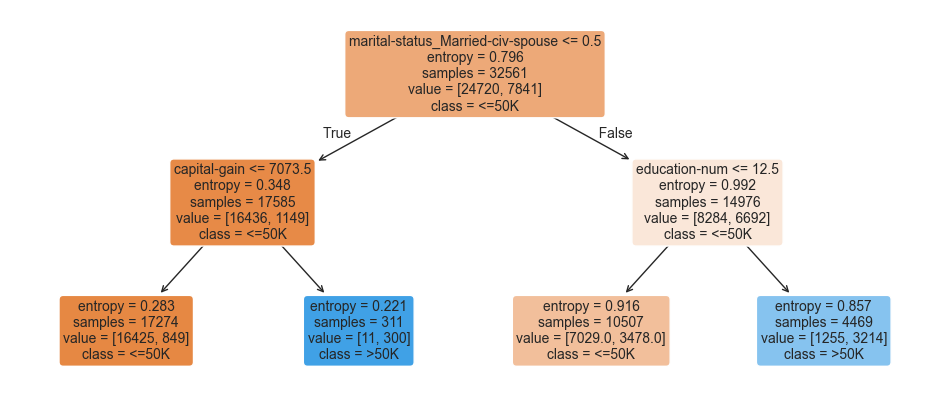

In [102]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,5)

_ = tree.plot_tree(arbol, filled=True, rounded=True, fontsize=10, feature_names=df_ohe.columns, class_names=arbol.classes_)

También podemos ver el porcentaje de aciertos o *accuracy* obtenido con el árbol tanto en el conjunto de entrenamiento como en el de test mediante el método `score()`:

In [103]:
print('Accuracy train:\t', arbol.score(X_ohe,y))
print('Accuracy test: \t', arbol.score(X_test_ohe,y_test))

Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227


Como el árbol que hemos creado está muy limitado a solo dos niveles de profundidad, el rendimiento del algoritmo en los datos de test es igual o incluso superior al que obtiene al intentar predecir directamente los mismos datos de entrenamiento con los que ha sido entrenado. Para comparar, vamos a crear un árbol por defecto (sin limitar):

In [104]:
arbol2 = DecisionTreeClassifier()
arbol2.fit(X_ohe,y)

DecisionTreeClassifier()

Si vemos la puntuación que obtiene, al no estar limitado, sobreajusta al máximo a los datos de entrenamiento (se los está aprendiendo de memoria). Esto hace que luego en el conjunto de test obtenga un resultado mucho peor, incluso peor al del árbol básico de 2 niveles.

In [105]:
print('Accuracy train:\t', arbol2.score(X_ohe,y))
print('Accuracy test: \t', arbol2.score(X_test_ohe,y_test))

Accuracy train:	 0.9999692884125181
Accuracy test: 	 0.8111295374976967


**Nota:** Este árbol no lo dibujamos porque al ser tan grande, tarda una eternidad y no se ve nada. El árbol limitado tenía 7 nodos, este tiene 9343:

In [106]:
print('Número de nodos limitado:', arbol.tree_.node_count)
print('Número de nodos hoja limitado:', arbol.tree_.n_leaves)

print('\nNúmero de nodos:', arbol2.tree_.node_count)
print('Número de nodos hoja:', arbol2.tree_.n_leaves)

Número de nodos limitado: 7
Número de nodos hoja limitado: 4

Número de nodos: 9313
Número de nodos hoja: 4657


## **<font color="#B30033" size=6>TAREA: </font>** Estudio de diferentes configuraciones

Debes llevar a cabo un estudio donde debes variar los hiperparámetros del árbol para obtener un buen clasificador. Además, como mínimo se debe mostrar información sobre el `score` obtenido tanto con los datos de entrenamiento como de test, el número de nodos del árbol y la cantidad de nodos hoja del mismo. 

Después responde a las siguientes preguntas:
* ¿Qué efecto observas con la variación de cada uno de los parámetros?
* ¿Qué configuración escogerías para obtener un buen clasificador? Justifica tu respuesta.

Consejos:
* Fíjate en los parámetros por defecto del algoritmo y en la explicación proporcionada para ajustar correctamente los valores. 
* Los datos están desbalanceados (hay muchos más casos para el valor de la clase `<=50K` que para `>50K`, como se puede ver en la primera de las gráficas de abajo). En este caso, si predecimos siempre `<=50K` obtenemos un 0.7592 de accuracy, cuando está claro que es una predicción muy mala. Por ello, puede ser interesante utilizar además otras métricas como por ejemplo F-score ([`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) en `scikit-learn`) que tengan en cuenta los valores de *precision* and *recall*. 
* Se recomienda también mostrar información en forma de gráficas, ya pueden ser en el propio Python o incluso con Excel. En Python, una de las opciones más sencillas es usar la librería `seaborn`. A continuación se dejan una serie de ejemplos de gráficas usando `seaborn`.

In [107]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

# Métricas accuracy y F1 cuando se predice siempre la clase mayoritaria
print('Zero-R accuracy: ', accuracy_score(y == '>50K', np.repeat(0, len(y))))
print('Zero-R F-score: ', f1_score(y == '>50K', np.repeat(0, len(y))))

Zero-R accuracy:  0.7591904425539756
Zero-R F-score:  0.0


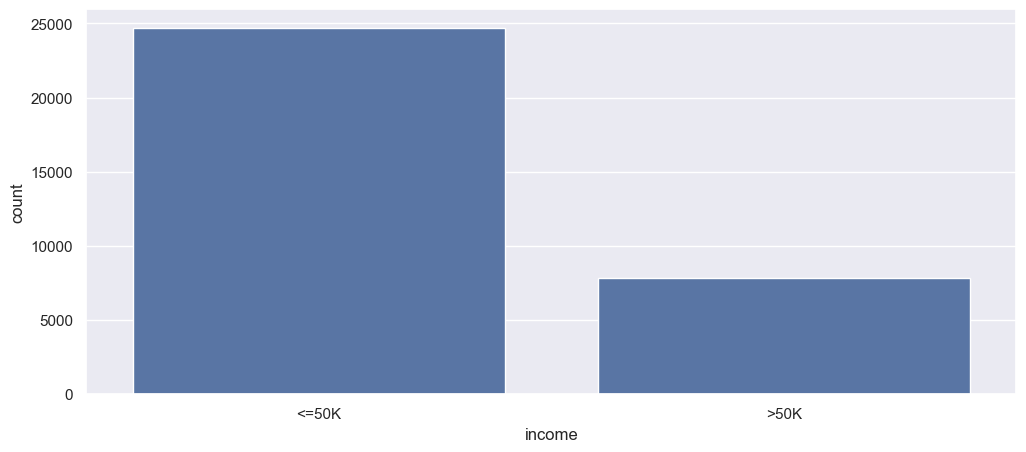

In [108]:
import seaborn as sns
sns.set(style="darkgrid")

# Número de valores para cada clase (categórica)
g = sns.countplot(df, x=target)

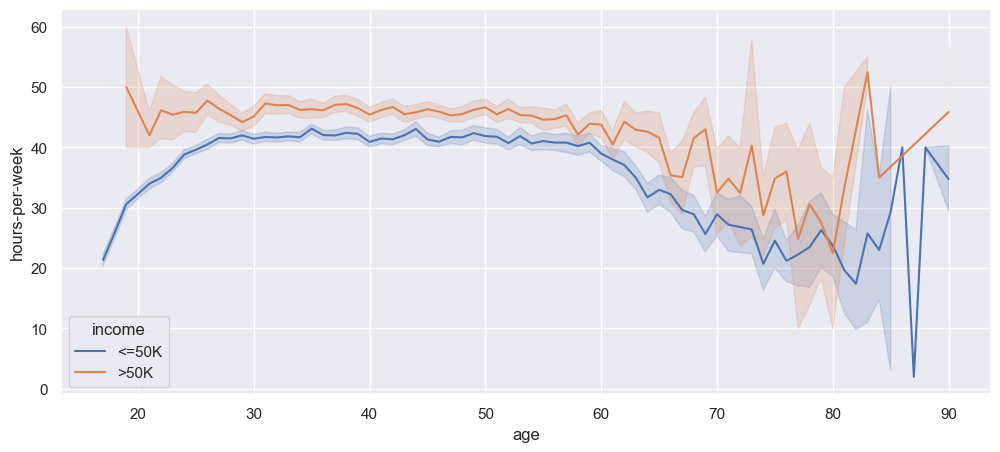

In [109]:
# Relación entre la edad (numérica) y las horas de trabajo por semana (numérica), diferenciando por clase
g = sns.lineplot(df, x='age', y='hours-per-week', hue='income')

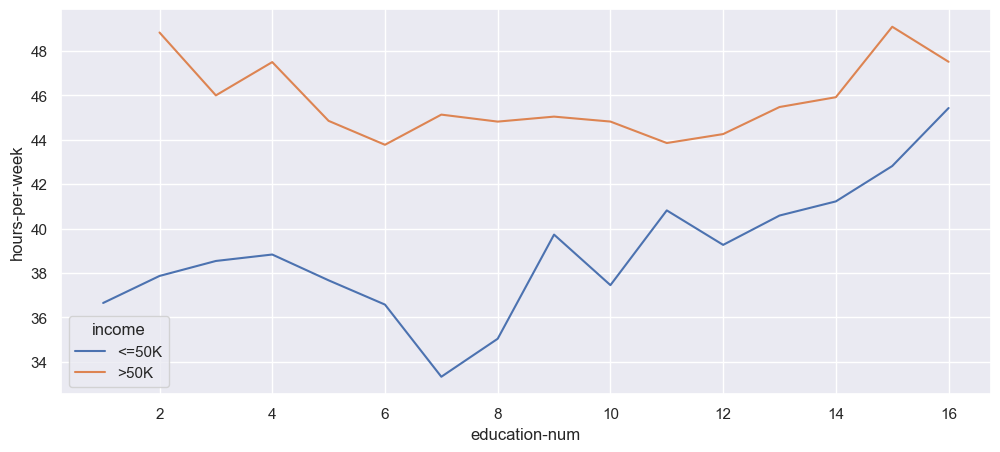

In [110]:
# Relación entre el nivel de educación (numérica) y las horas de trabajo por semana (numérica), diferenciando por clase y eliminando los intervalos de confianza
g = sns.lineplot(df, x='education-num', y='hours-per-week', hue='income', errorbar=None)

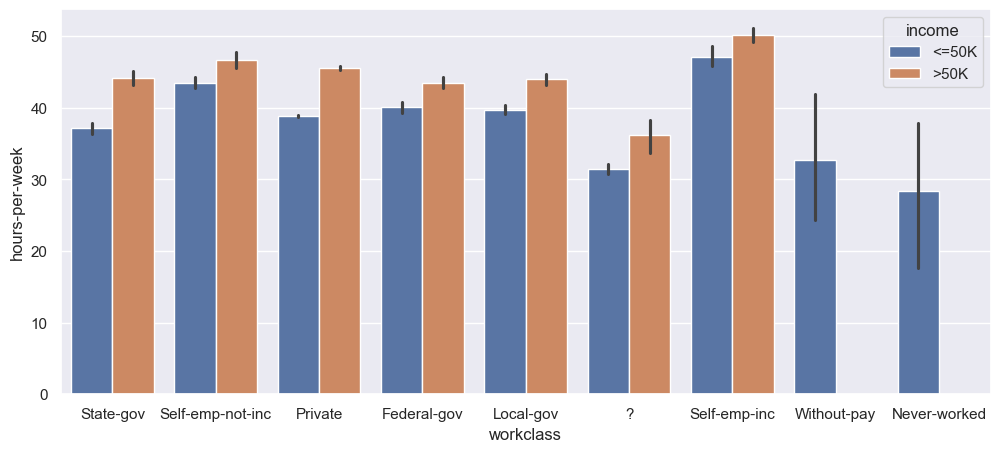

In [111]:
# Relación entre el tipo de trabajo (categórica) y las horas de trabajo por semana (numérica), diferenciando por clase
g = sns.barplot(df, x='workclass', y='hours-per-week', hue='income')

In [112]:
#En esta celda se va a realizar una funcion para que sea la que realice los experimentos
import time as t

def experimento(df,df_test,criterion,prof,min_muestras):
    df_ohe = pd.get_dummies(df.drop(target, axis=1)) #Nuevo dataframe con variables predictoras. Elimina última variable (si o no <50K). Divide en columnas binarias
    df_test_ohe = pd.get_dummies(df_test.drop(target, axis=1))
    df_ohe, df_test_ohe = df_ohe.align(df_test_ohe, join='outer', axis=1, fill_value=0) #Mismas columnas mismo orden. Axis->Columna. Rellenar con 0

    y,y_test= df[target].to_numpy(),df_test[target].to_numpy() #Crea los 2 vectores. Pasa columna pandas a array de numpy con income
    X_ohe, X_test_ohe = df_ohe.to_numpy(), df_test_ohe.to_numpy()

    arbol = DecisionTreeClassifier(criterion=criterion,max_depth=prof,min_samples_leaf=min_muestras)
    arbol.fit(X_ohe,y) #Fit entrena modelo

    puntuacion,puntuacion_test = arbol.score(X_ohe,y),arbol.score(X_test_ohe,y_test) #Saca % aciertos(Accuracy)
    print('Accuracy train:\t', puntuacion)
    print('Accuracy test: \t', puntuacion_test)

    return (puntuacion,puntuacion_test)

Hemos desarrollado la función `experimento`. En estos experimentos vamos a graficar tanto la precisión como el tiempo con respecto a las distintas variables que se nos presentan.
<br><br>
Primero variaremos la profundidad en el eje x, y el número de hojas por nodo en cada imagen. Posteriormente, analizaremos los datos comparando su accuracy, los criterios 'entropy', 'gini' y cuánto tarda en realizarse

Profundidad 2
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 3
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 4
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 5
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 6
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 7
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 8
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 9
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 10
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 11
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 12
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 13
Accuracy train:	 0.8193544424311293


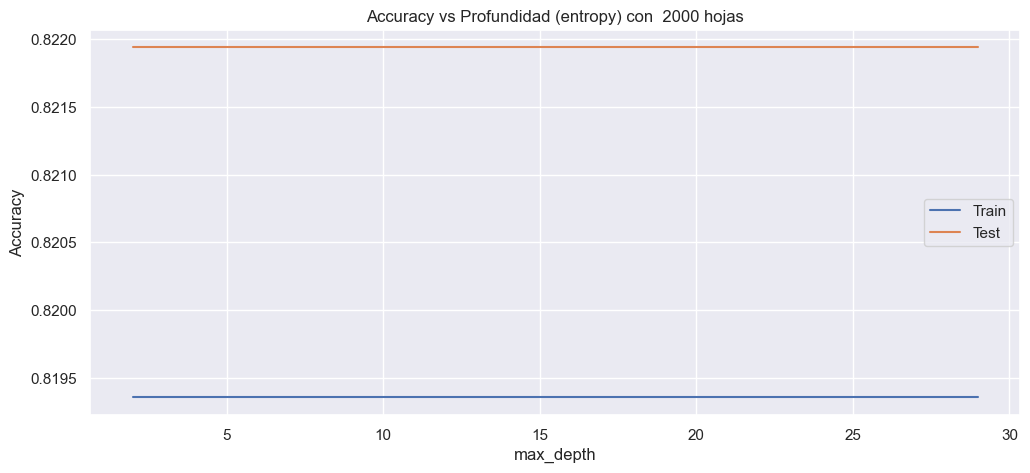

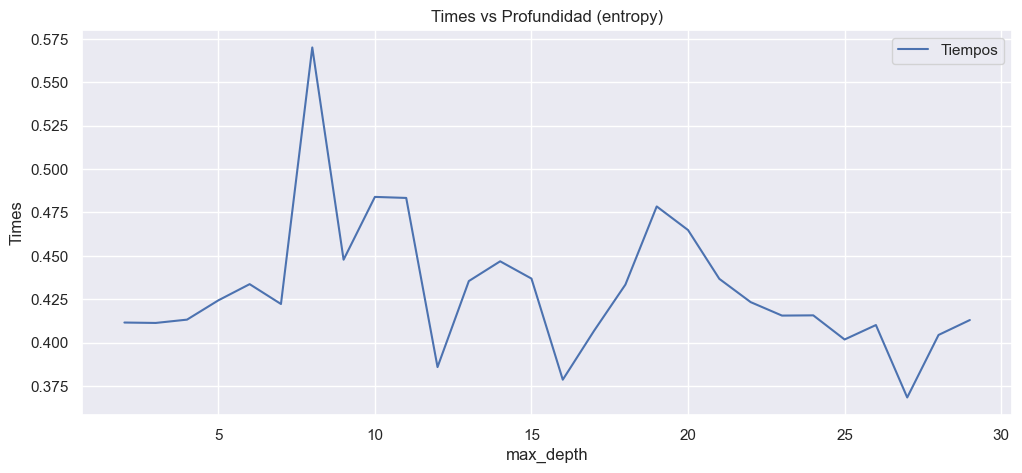

Profundidad 2
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 3
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 4
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 5
Accuracy train:	 0.8222720432419152
Accuracy test: 	 0.8228610036238561
Profundidad 6
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 7
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 8
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 9
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 10
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 11
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 12
Accuracy train:	 0.8243297196032063
Accuracy test: 	 0.8251335913027456
Profundidad 13
Accuracy train:	 0.8243297196032063


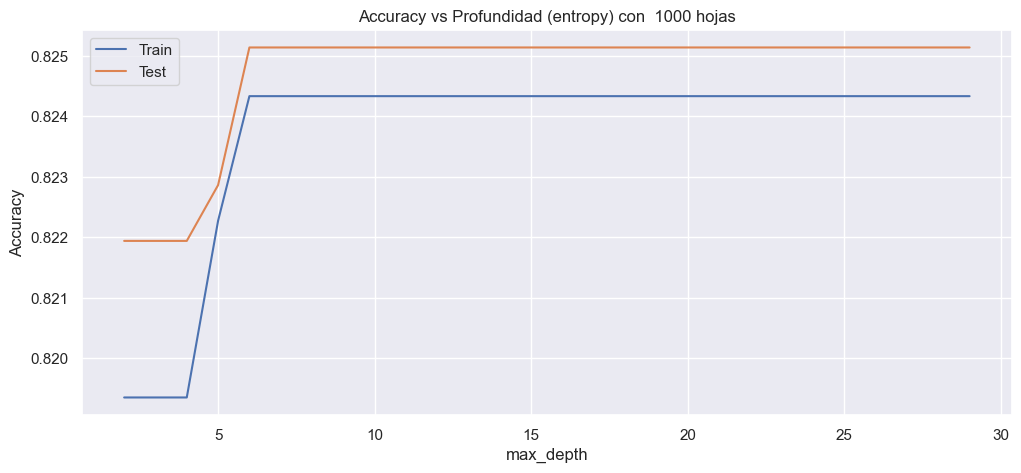

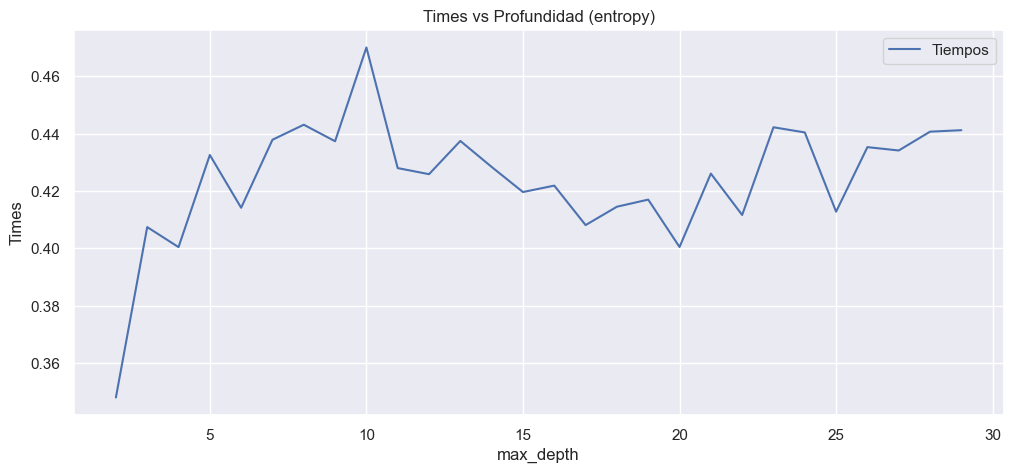

Profundidad 2
Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227
Profundidad 3
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 4
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 5
Accuracy train:	 0.8462885046528055
Accuracy test: 	 0.847122412628217
Profundidad 6
Accuracy train:	 0.8520008599244495
Accuracy test: 	 0.8534488053559364
Profundidad 7
Accuracy train:	 0.8527072264365345
Accuracy test: 	 0.8530802776242246
Profundidad 8
Accuracy train:	 0.8527072264365345
Accuracy test: 	 0.8530802776242246
Profundidad 9
Accuracy train:	 0.8527072264365345
Accuracy test: 	 0.8530802776242246
Profundidad 10
Accuracy train:	 0.8564233285218513
Accuracy test: 	 0.8563356059210122
Profundidad 11
Accuracy train:	 0.8564540401093332
Accuracy test: 	 0.8559056569006818
Profundidad 12
Accuracy train:	 0.8581738890083228
Accuracy test: 	 0.8575026104047663
Profundidad 13
Accuracy train:	 0.8591566598077455
Acc

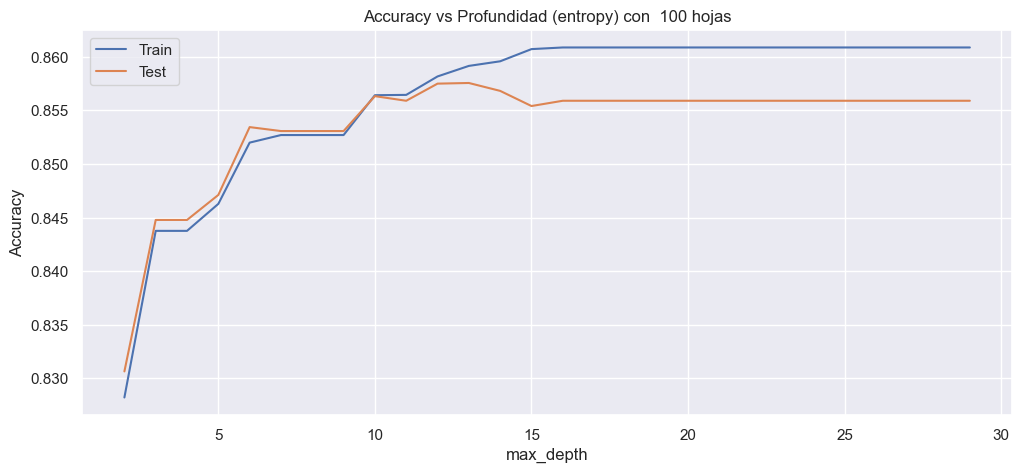

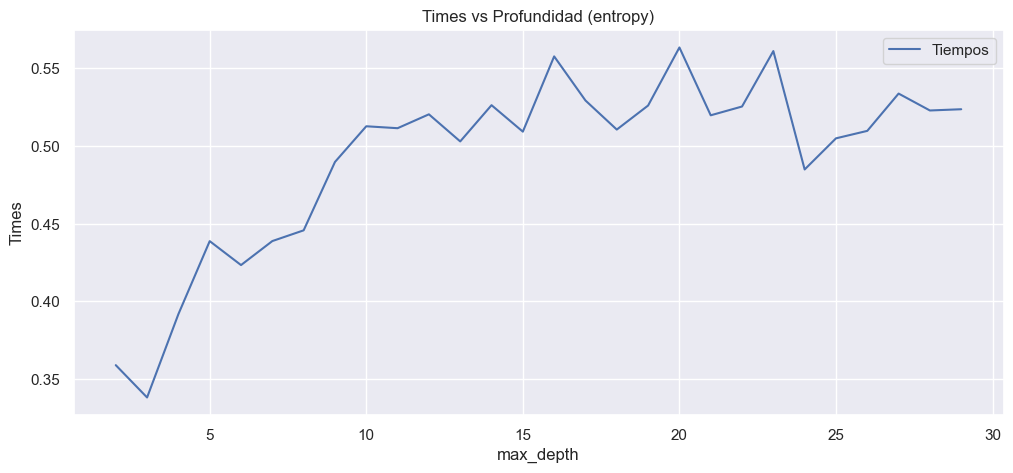

Profundidad 2
Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227
Profundidad 3
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 4
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 5
Accuracy train:	 0.8462885046528055
Accuracy test: 	 0.847122412628217
Profundidad 6
Accuracy train:	 0.8533214581861737
Accuracy test: 	 0.8546772311283091
Profundidad 7
Accuracy train:	 0.8558090967722122
Accuracy test: 	 0.8562127633437749
Profundidad 8
Accuracy train:	 0.8578053499585394
Accuracy test: 	 0.8563356059210122
Profundidad 9
Accuracy train:	 0.8592795061576733
Accuracy test: 	 0.8581782445795713
Profundidad 10
Accuracy train:	 0.8628113387180983
Accuracy test: 	 0.8617406793194521
Profundidad 11
Accuracy train:	 0.8643469180921962
Accuracy test: 	 0.8597137767950371
Profundidad 12
Accuracy train:	 0.8660974785786677
Accuracy test: 	 0.8590995639088508
Profundidad 13
Accuracy train:	 0.8696907343140567
Acc

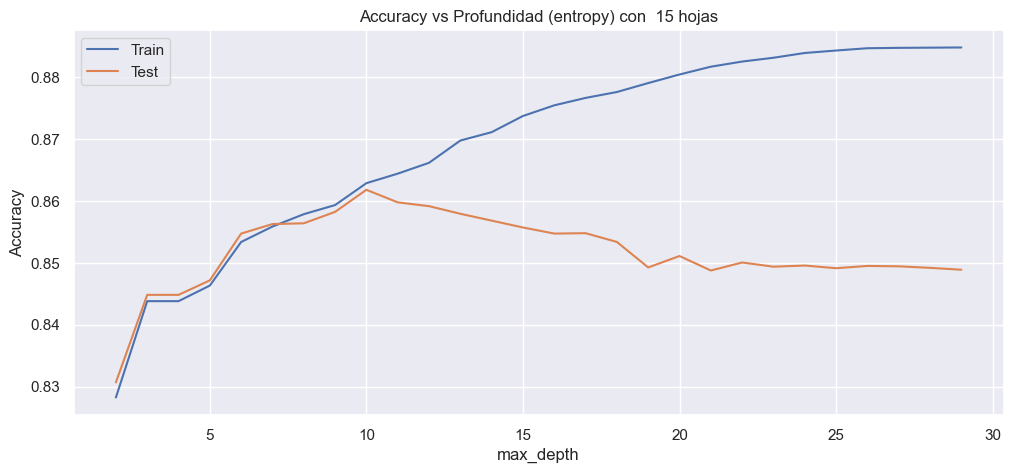

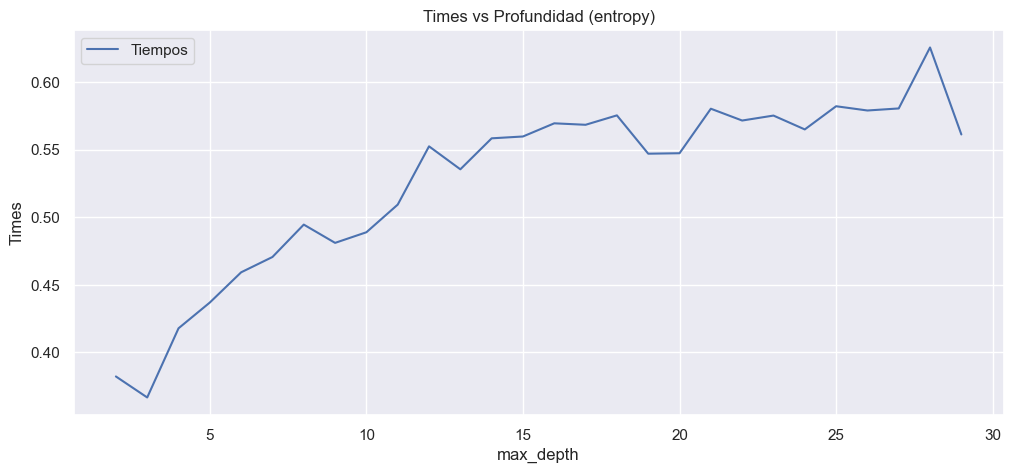

Profundidad 2
Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227
Profundidad 3
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 4
Accuracy train:	 0.8438930008292128
Accuracy test: 	 0.8447884036607088
Profundidad 5
Accuracy train:	 0.8465341973526611
Accuracy test: 	 0.8469995700509797
Profundidad 6
Accuracy train:	 0.8536899972359572
Accuracy test: 	 0.8546772311283091
Profundidad 7
Accuracy train:	 0.8565154632842972
Accuracy test: 	 0.856028499477919
Profundidad 8
Accuracy train:	 0.8589723902828538
Accuracy test: 	 0.8570112400958172
Profundidad 9
Accuracy train:	 0.8614907404563742
Accuracy test: 	 0.8571340826730545
Profundidad 10
Accuracy train:	 0.8653296888916188
Accuracy test: 	 0.8616178367422148
Profundidad 11
Accuracy train:	 0.8686465403396701
Accuracy test: 	 0.8585467723112831
Profundidad 12
Accuracy train:	 0.8716869875003839
Accuracy test: 	 0.8576868742706222
Profundidad 13
Accuracy train:	 0.87586376339793
Accu

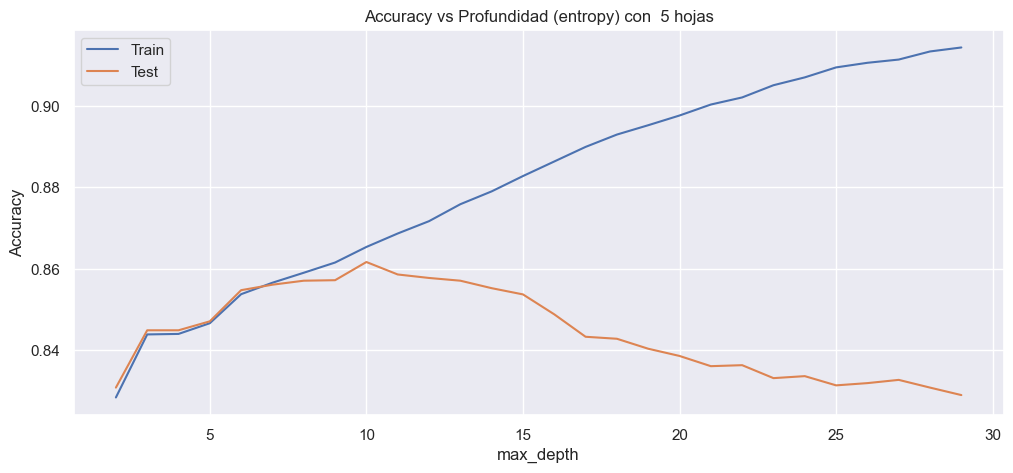

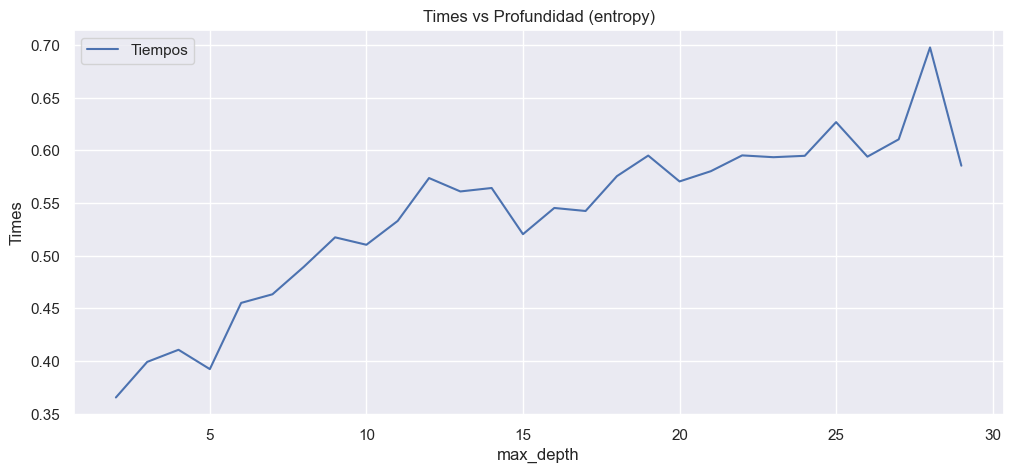

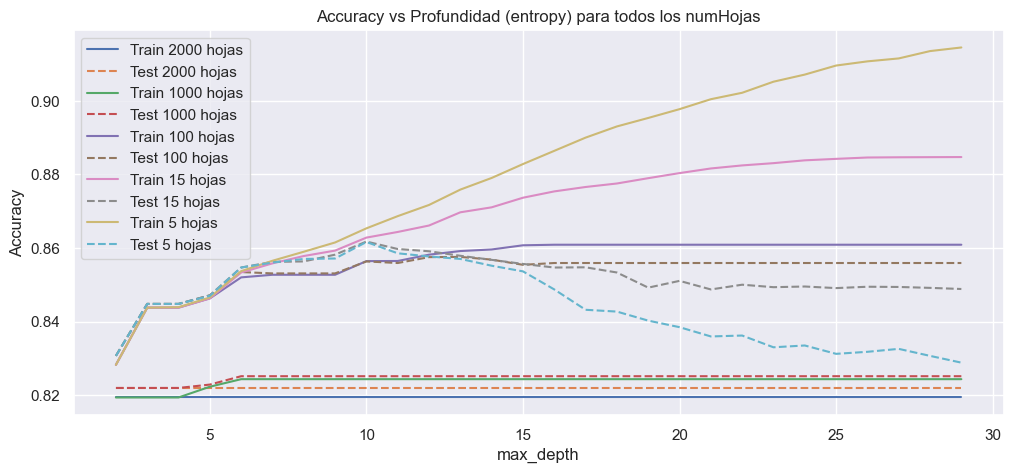

Profundidad 2
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 3
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 4
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 5
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 6
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 7
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 8
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 9
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 10
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 11
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 12
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 13
Accuracy train:	 0.8193544424311293


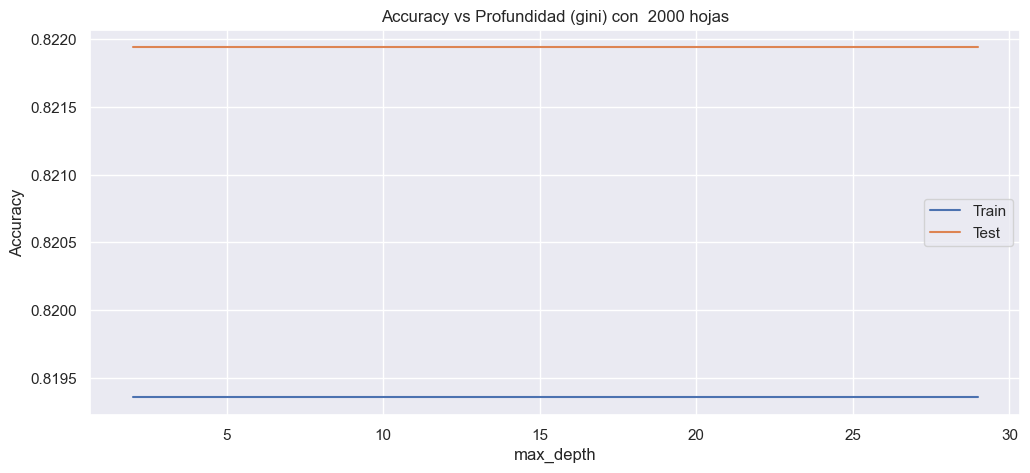

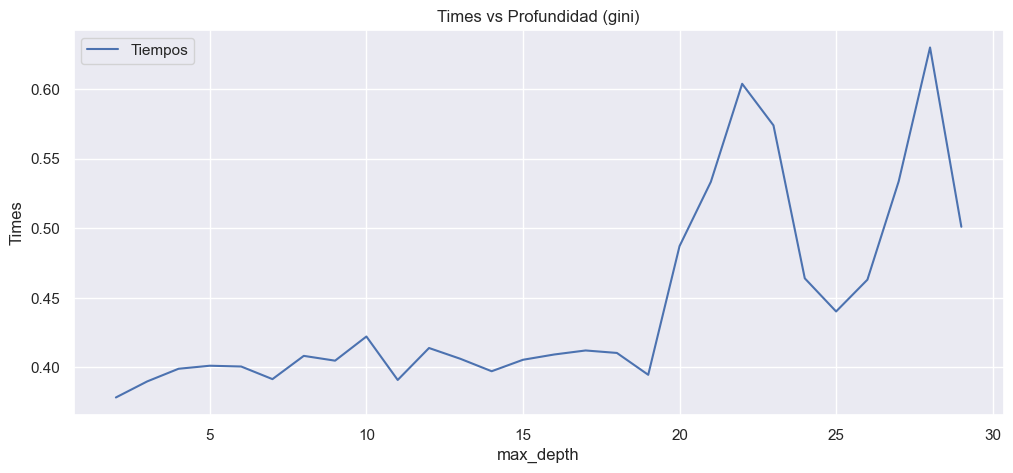

Profundidad 2
Accuracy train:	 0.8193544424311293
Accuracy test: 	 0.8219396842945765
Profundidad 3
Accuracy train:	 0.8265716654893891
Accuracy test: 	 0.8296787666605245
Profundidad 4
Accuracy train:	 0.8265716654893891
Accuracy test: 	 0.8296787666605245
Profundidad 5
Accuracy train:	 0.8265716654893891
Accuracy test: 	 0.8296787666605245
Profundidad 6
Accuracy train:	 0.8265716654893891
Accuracy test: 	 0.8296787666605245
Profundidad 7
Accuracy train:	 0.8278615521636313
Accuracy test: 	 0.8296787666605245
Profundidad 8
Accuracy train:	 0.8278615521636313
Accuracy test: 	 0.8296787666605245
Profundidad 9
Accuracy train:	 0.8278615521636313
Accuracy test: 	 0.8296787666605245
Profundidad 10
Accuracy train:	 0.8278615521636313
Accuracy test: 	 0.8296787666605245
Profundidad 11
Accuracy train:	 0.8278615521636313
Accuracy test: 	 0.8296787666605245
Profundidad 12
Accuracy train:	 0.8278615521636313
Accuracy test: 	 0.8296787666605245
Profundidad 13
Accuracy train:	 0.8278615521636313


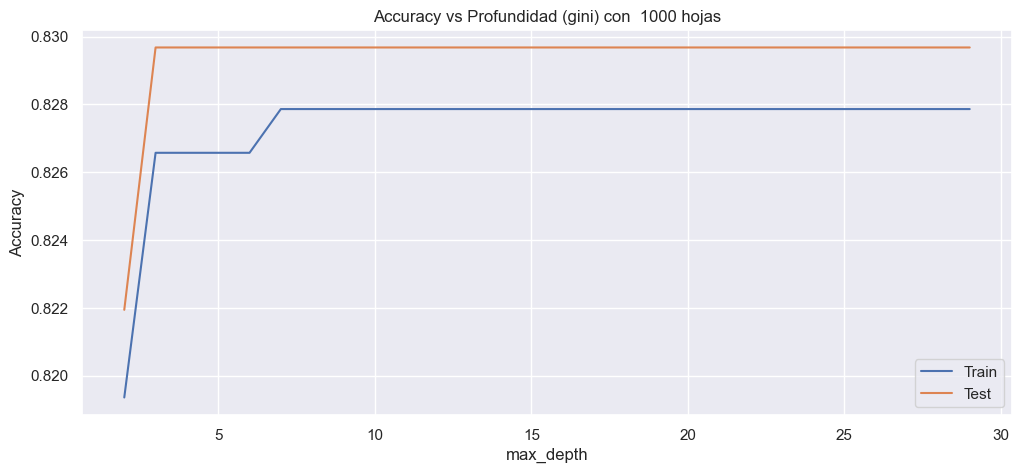

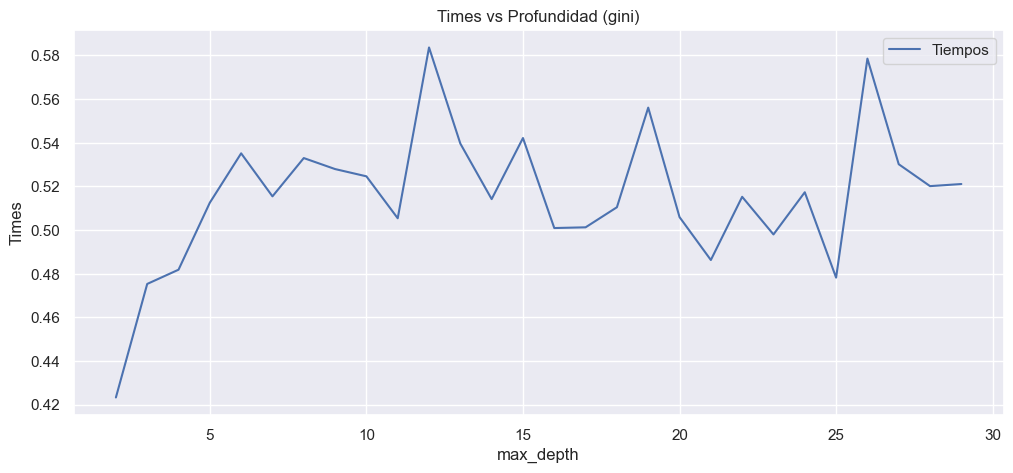

Profundidad 2
Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227
Profundidad 3
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 4
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 5
Accuracy train:	 0.8514787629372562
Accuracy test: 	 0.8525274860266568
Profundidad 6
Accuracy train:	 0.8529222075489082
Accuracy test: 	 0.85418586081936
Profundidad 7
Accuracy train:	 0.8536285740609932
Accuracy test: 	 0.8538173330876482
Profundidad 8
Accuracy train:	 0.8536285740609932
Accuracy test: 	 0.8538173330876482
Profundidad 9
Accuracy train:	 0.8536285740609932
Accuracy test: 	 0.8538173330876482
Profundidad 10
Accuracy train:	 0.8578974847209853
Accuracy test: 	 0.8570726613844358
Profundidad 11
Accuracy train:	 0.8579281963084672
Accuracy test: 	 0.8566427123641054
Profundidad 12
Accuracy train:	 0.8595866220324928
Accuracy test: 	 0.8565812910754868
Profundidad 13
Accuracy train:	 0.8601087190196861
Accu

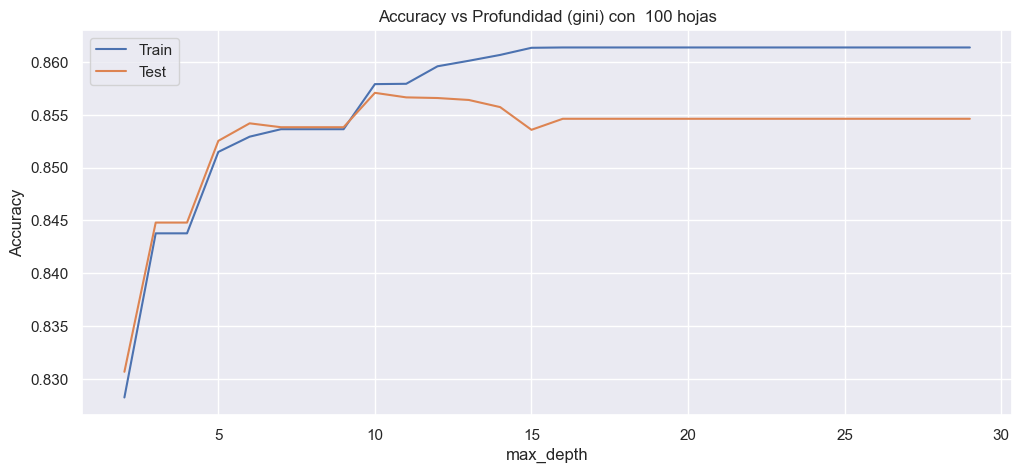

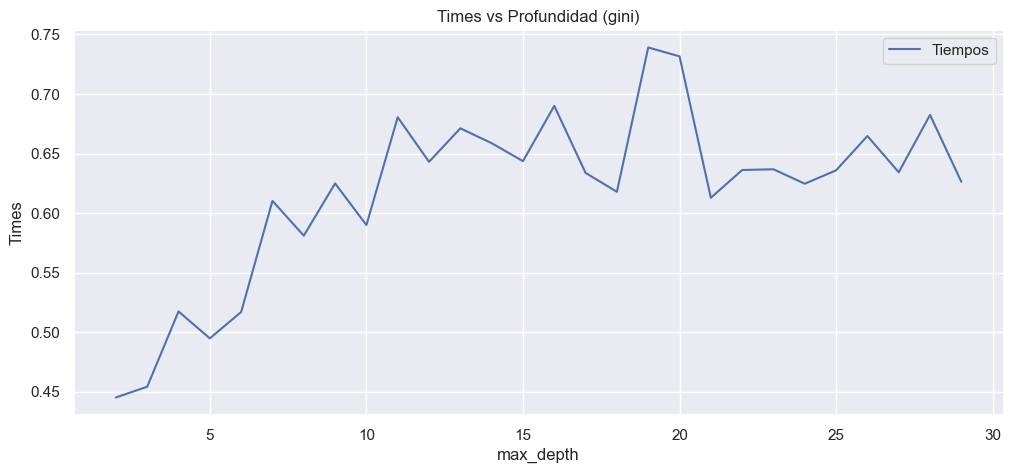

Profundidad 2
Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227
Profundidad 3
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 4
Accuracy train:	 0.843770154479285
Accuracy test: 	 0.8447884036607088
Profundidad 5
Accuracy train:	 0.8517858788120758
Accuracy test: 	 0.8523432221608009
Profundidad 6
Accuracy train:	 0.8562697705844415
Accuracy test: 	 0.8573183465389104
Profundidad 7
Accuracy train:	 0.85734467614631
Accuracy test: 	 0.8571955039616731
Profundidad 8
Accuracy train:	 0.8586959859955161
Accuracy test: 	 0.8572569252502917
Profundidad 9
Accuracy train:	 0.8599858726697583
Accuracy test: 	 0.8588538787543762
Profundidad 10
Accuracy train:	 0.8648997266668714
Accuracy test: 	 0.8622320496284012
Profundidad 11
Accuracy train:	 0.8664967292159331
Accuracy test: 	 0.8593452490633253
Profundidad 12
Accuracy train:	 0.8679401738275851
Accuracy test: 	 0.8595909342177999
Profundidad 13
Accuracy train:	 0.8717791222628297
Accu

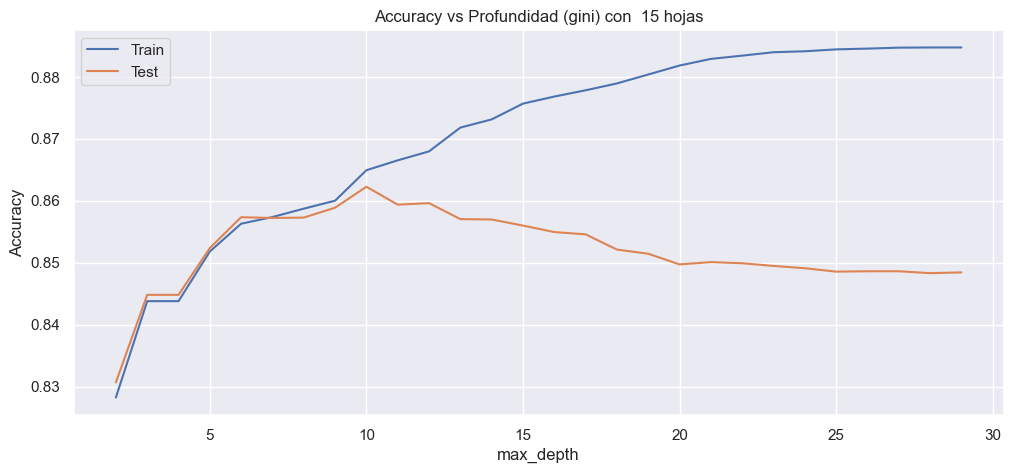

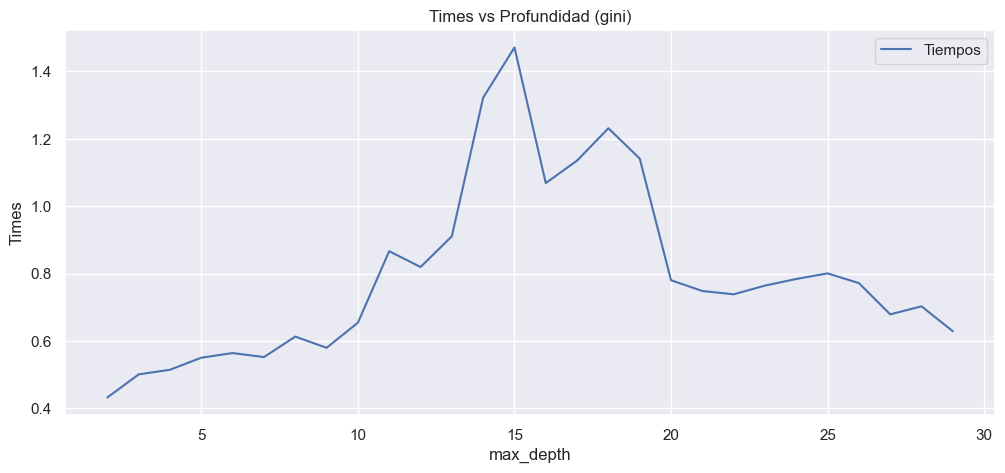

Profundidad 2
Accuracy train:	 0.8282300912134148
Accuracy test: 	 0.8306615072784227
Profundidad 3
Accuracy train:	 0.8438622892417309
Accuracy test: 	 0.8447884036607088
Profundidad 4
Accuracy train:	 0.8438622892417309
Accuracy test: 	 0.8447884036607088
Profundidad 5
Accuracy train:	 0.8520008599244495
Accuracy test: 	 0.8523432221608009
Profundidad 6
Accuracy train:	 0.8567918675716347
Accuracy test: 	 0.8577482955592408
Profundidad 7
Accuracy train:	 0.8581738890083228
Accuracy test: 	 0.8575640316933849
Profundidad 8
Accuracy train:	 0.8595559104450109
Accuracy test: 	 0.8573183465389104
Profundidad 9
Accuracy train:	 0.8623199533183871
Accuracy test: 	 0.8588538787543762
Profundidad 10
Accuracy train:	 0.8678173274776573
Accuracy test: 	 0.8616792580308335
Profundidad 11
Accuracy train:	 0.8703971008261417
Accuracy test: 	 0.8597137767950371
Profundidad 12
Accuracy train:	 0.8736525290992292
Accuracy test: 	 0.8583625084454272
Profundidad 13
Accuracy train:	 0.8789042105586438


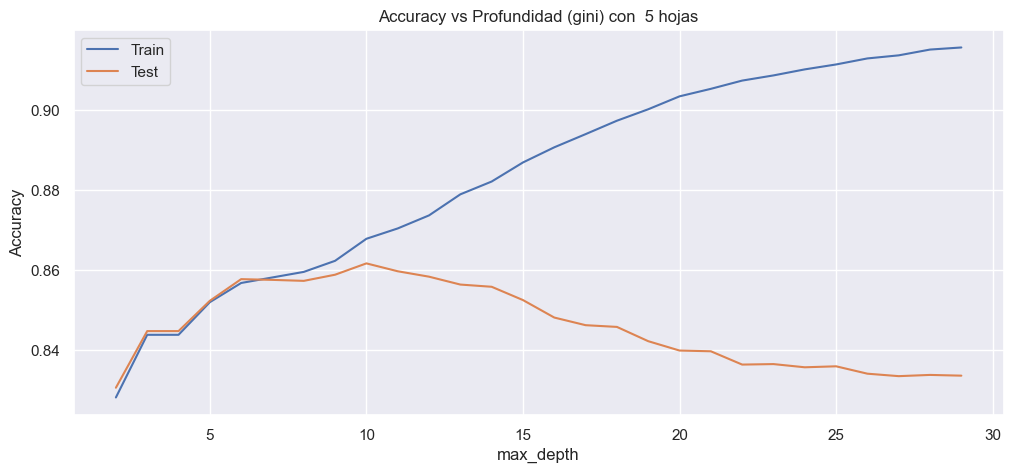

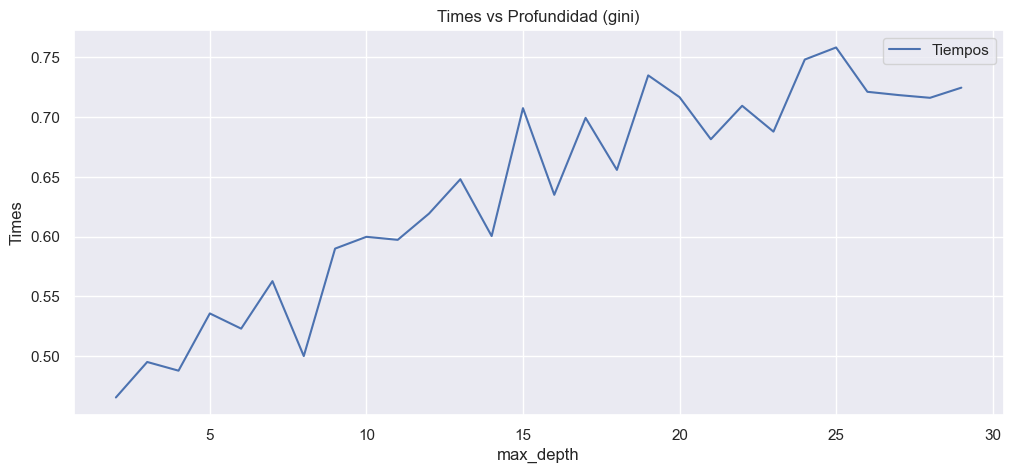

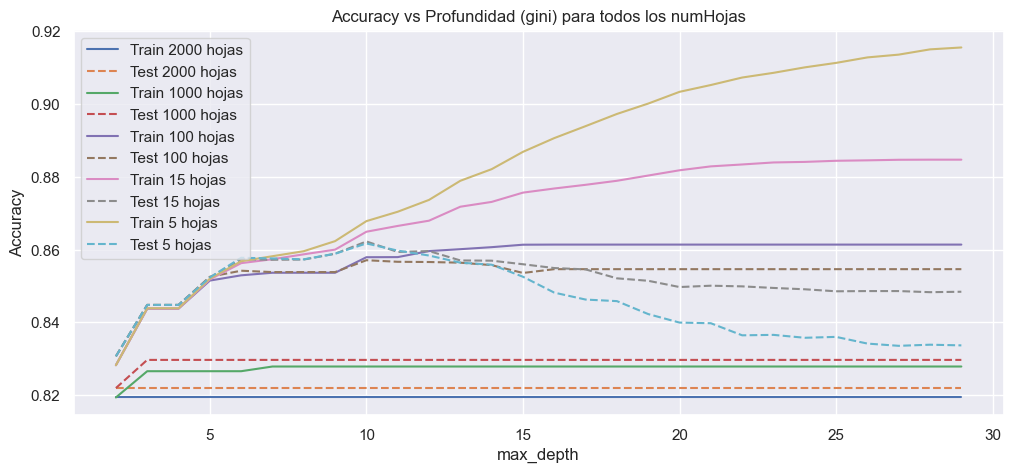

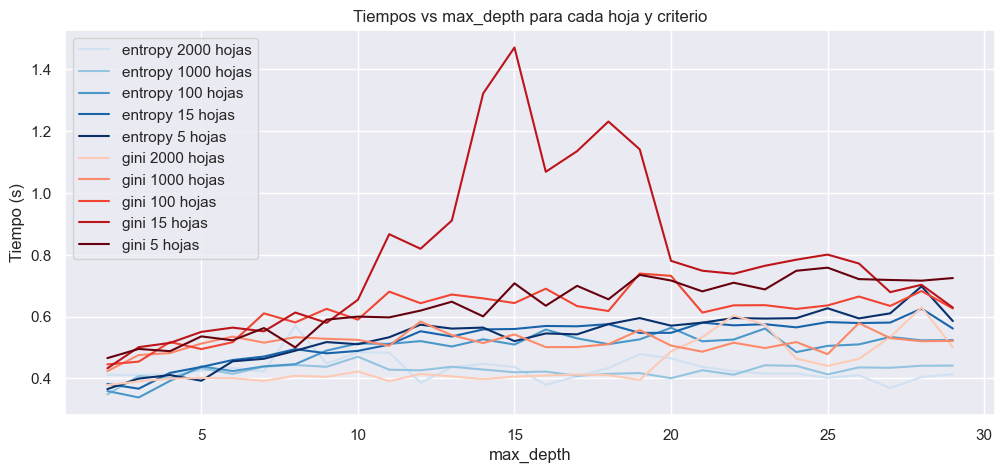

In [113]:
#En estos experimentos vamos a graficar tanto la precisión como el tiempo con respecto a las distintas variables que se nos presentan
#Primero establecemos una lista con los distintos criterios de evaluacion
criterios = ['entropy','gini']


#En estos experimentos vamos a graficar tanto la precisión como el tiempo con respecto a las distintas variables que se nos presentan
#Primero establecemos una lista con los distintos criterios de evaluacion
criterios = ['entropy','gini']
hojas = [2000,1000,100,15,5]

tiempos_criterio = {} #Guardamos los tiempos con respectivo criterio
#Aqui realizaremos los experimentos para distinto numero de profundidades, manteniendo el min_samples_leaf a 2000
for c in criterios:
    todos_datos = [] #Matriz para dibujo final comparando todo
    todos_datos_test = []
    tiempo_tot = []

    for numHojas in hojas:
      tiempos = []
      precision = []
      precision_test = []
      
      for i in range (2,30): #Variamos max depth
        print("Profundidad", i )
        inicio = t.time()
        p,p_t = experimento(df,df_test,c,i,numHojas) #Hacer el experimento con los ejemplos con numHojas q toquen
        tiempos.append(t.time() - inicio) 
        precision.append(p)
        precision_test.append(p_t)
      todos_datos.append(precision) #Guardamos todas precisiones
      todos_datos_test.append(precision_test)
      tiempo_tot.append(tiempos)
        

      #Hago las gráficas
      profundidades = list(range(2,30))

      plt.figure() #Dibujo gráfica de accuracy
      plt.plot(profundidades, precision, label="Train")
      plt.plot(profundidades, precision_test, label="Test")
      plt.xlabel("max_depth")
      plt.ylabel("Accuracy")
      plt.title(f"Accuracy vs Profundidad ({c}) con  {numHojas} hojas")
      plt.legend()
      plt.show()

      plt.figure() #Dibujo gráfica de tiempos
      plt.plot(profundidades, tiempos, label="Tiempos")
      plt.xlabel("max_depth")
      plt.ylabel("Times")
      plt.title(f"Times vs Profundidad ({c})")
      plt.legend()
      plt.show()

    #plt.figure(figsize=(10,6))
    for indice, nHojas in enumerate(hojas): #devuelve tupla (0,2000),(1,1000),(2,100)...
       plt.plot(range(2,30), todos_datos[indice], label=f"Train {nHojas} hojas")
       plt.plot(range(2,30), todos_datos_test[indice], '--', label=f"Test {nHojas} hojas")
    plt.xlabel("max_depth")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs Profundidad ({c}) para todos los numHojas")
    plt.legend()
    plt.grid(True)
    plt.show()

    tiempos_criterio[c] = tiempo_tot #filas=hojas, columnas=depth
  
  
#plt.figure(figsize=(12,6))
for c in criterios:
    if c == 'entropy': #Si criterio entropia, metemoz azul
        colormap = cm.Blues   
    else: #si no, rojo
        colormap = cm.Reds    

    #Normalizamos los índices de hojas para usar el colormap
    norm = np.linspace(0.2, 1.0, len(hojas))#más alto = más hojas

    for i, nHojas in enumerate(hojas):
        color = colormap(norm[i])
        plt.plot(range(2,30), tiempos_criterio[c][i], label=f"{c} {nHojas} hojas", color=color)

plt.xlabel("max_depth")
plt.ylabel("Tiempo (s)")
plt.title("Tiempos vs max_depth para cada hoja y criterio")
plt.legend()
plt.grid(True)
plt.show()



<h2><font size=6>Estudio de las gráficas obtenidas</font></h2><br>

Una vez ejecutado el código, hemos obtenido las gráficas comparando los criterios en relación a su tiempo de ejecución, su profundidad y su número de hojas.<br>

Como era de esperar, los factores profundidad y número de hojas son muy influyentes a la hora de realizar el experimento. El tiempo tiene una relación directamente proporcional con estos dos factores.<br>

Cuando hay muchas hojas, los resultados en train son ligeramente superiores, es decir, nuestro modelo es exitoso a la hora de testearlo, pero la precisión se podría mejorar disminuyendo el número de hojas por nodo<br><br>

Se observa que cuando el número de hojas es pequeño, la precisión en train es mucho mayor que en test. Esto indica que el modelo está memorizando demasiado los datos de entrenamiento y no generaliza bien a datos nuevos, es decir, se está produciendo un sobreajuste. Este sobreajuste se refleja en la separación creciente entre las curvas de train y test a medida que disminuye el número de hojas, señalando el inicio del sobreajuste. <br>



<br>
Podemos ver que se produce un sobreajuste cuando hay muy pocas hojas. A partir de las 100 hojas en nuestras gráficas, se produce un sobreajuste, el cual ahora calcularemos el punto exacto en el que se produce. 


Accuracy train:	 0.8796720002456927
Accuracy test: 	 0.8546158098396904
Accuracy train:	 0.8772457848346181
Accuracy test: 	 0.8544929672624532
Accuracy train:	 0.8745431651362059
Accuracy test: 	 0.8570726613844358
Accuracy train:	 0.8732532784619637
Accuracy test: 	 0.8565812910754868
Accuracy train:	 0.8721476613126132
Accuracy test: 	 0.8575026104047663
Accuracy train:	 0.8712263136881545
Accuracy test: 	 0.8579939807137154
Accuracy train:	 0.8699978501888762
Accuracy test: 	 0.858055402002334
Accuracy train:	 0.8695678879641289
Accuracy test: 	 0.8567655549413427
Accuracy train:	 0.868738675102116
Accuracy test: 	 0.8563356059210122
Accuracy train:	 0.8680937317649949
Accuracy test: 	 0.8565198697868681
Accuracy train:	 0.868032308590031
Accuracy test: 	 0.8568269762299613
Accuracy train:	 0.8677866158901754
Accuracy test: 	 0.8570112400958172
Accuracy train:	 0.867325942077946
Accuracy test: 	 0.856704133652724
Accuracy train:	 0.8668345566782347
Accuracy test: 	 0.85731834653891

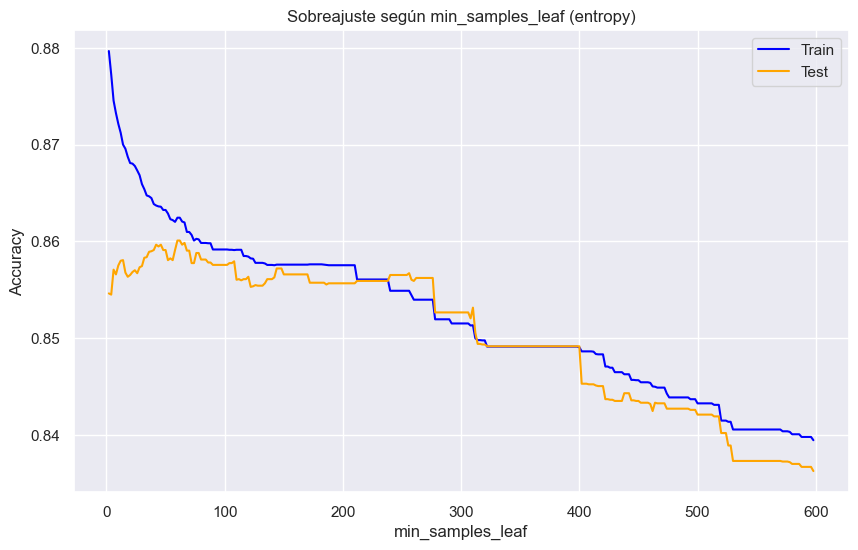

Accuracy train:	 0.8849851048800712
Accuracy test: 	 0.8505620047908605
Accuracy train:	 0.8809618869199349
Accuracy test: 	 0.8538787543762668
Accuracy train:	 0.8773072080095821
Accuracy test: 	 0.8562127633437749
Accuracy train:	 0.875925186572894
Accuracy test: 	 0.8579939807137154
Accuracy train:	 0.873806087036639
Accuracy test: 	 0.8571340826730545
Accuracy train:	 0.8728847394121803
Accuracy test: 	 0.8583010871568085
Accuracy train:	 0.8722397960750591
Accuracy test: 	 0.8562741846323936
Accuracy train:	 0.8713491600380824
Accuracy test: 	 0.856028499477919
Accuracy train:	 0.8695985995516108
Accuracy test: 	 0.8554142865917327
Accuracy train:	 0.8690150793894537
Accuracy test: 	 0.8549843375714022
Accuracy train:	 0.8688615214520439
Accuracy test: 	 0.8552914440144954
Accuracy train:	 0.8686772519271521
Accuracy test: 	 0.8554757078803513
Accuracy train:	 0.8682165781149228
Accuracy test: 	 0.8554757078803513
Accuracy train:	 0.8680015970025491
Accuracy test: 	 0.855230022725

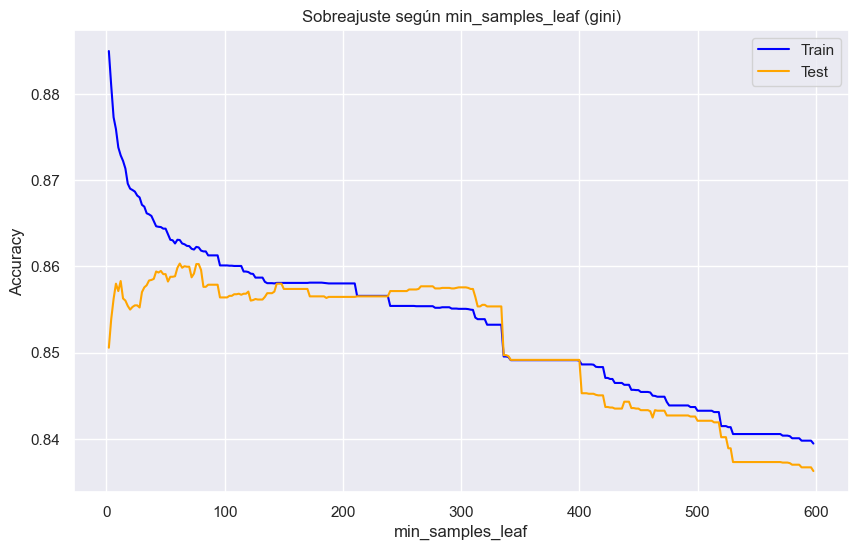

In [114]:
for c in criterios:
    precision=[]
    precision_test=[]
    for hojasVariable in range(2,600,2): #numHojas
        #print("Hojas",hojasVariable)
        p,p_t = experimento(df,df_test,c,13,hojasVariable) #Pongo 13 de profundidad pq en las gráficas parece un punto medio
        precision.append(p)
        precision_test.append(p_t)

    min_samples = list(range(2, 600, 2))

    plt.figure(figsize=(10,6))
    plt.plot(min_samples, precision, label="Train", color='blue')
    plt.plot(min_samples, precision_test, label="Test", color='orange')
    plt.xlabel("min_samples_leaf")
    plt.ylabel("Accuracy")
    plt.title(f"Sobreajuste según min_samples_leaf ({c})")
    plt.legend()
    plt.grid(True)
    plt.show()
    

Al inicio del train se tienen unos resultados excelentes, casi de un 90%, en cambio, su misma versión de test con el mismo número de hojas, no obtiene los mismos resultados. En el train, cada hoja tiene muy pocos datos, por tanto, se podría pensar que los está "memorizando". A la hora del test, no se tienen los mismos datos, por lo que no nos sería útil usar tan pocas hojas.

Ahora ahondaremos más e intentaremos sacar cual es la cantidad óptima de min_samples_leaf

Accuracy train:	 0.8823439083566229
Accuracy test: 	 0.854861494994165
Accuracy train:	 0.8796412886582108
Accuracy test: 	 0.8551071801486395
Accuracy train:	 0.878781364208716
Accuracy test: 	 0.8525274860266568
Accuracy train:	 0.8772457848346181
Accuracy test: 	 0.8556599717462072
Accuracy train:	 0.875894474985412
Accuracy test: 	 0.8558442356120631
Accuracy train:	 0.8746045883111698
Accuracy test: 	 0.8572569252502917
Accuracy train:	 0.8740824913239765
Accuracy test: 	 0.8560899207665377
Accuracy train:	 0.8733147016369276
Accuracy test: 	 0.856028499477919
Accuracy train:	 0.8727004698872884
Accuracy test: 	 0.8565198697868681
Accuracy train:	 0.8722090844875772
Accuracy test: 	 0.8571340826730545
Accuracy train:	 0.8716869875003839
Accuracy test: 	 0.8571955039616731
Accuracy train:	 0.8712263136881545
Accuracy test: 	 0.8579939807137154
Accuracy train:	 0.870243542888732
Accuracy test: 	 0.8579325594250967
Accuracy train:	 0.8699978501888762
Accuracy test: 	 0.85805540200233

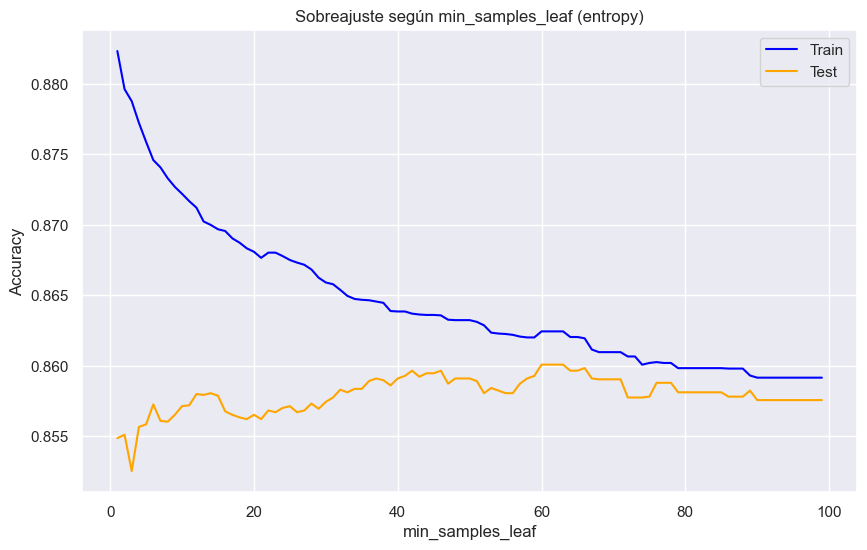

Accuracy train:	 0.8886704953779061
Accuracy test: 	 0.850991953811191
Accuracy train:	 0.8848622585301434
Accuracy test: 	 0.850991953811191
Accuracy train:	 0.8832038328061177
Accuracy test: 	 0.8507462686567164
Accuracy train:	 0.8810233100948988
Accuracy test: 	 0.8536944905104109
Accuracy train:	 0.8789042105586438
Accuracy test: 	 0.8561513420551563
Accuracy train:	 0.8773072080095821
Accuracy test: 	 0.8565812910754868
Accuracy train:	 0.8768158226098707
Accuracy test: 	 0.8562127633437749
Accuracy train:	 0.875925186572894
Accuracy test: 	 0.8579325594250967
Accuracy train:	 0.8748809925985074
Accuracy test: 	 0.8582396658681899
Accuracy train:	 0.8736832406867111
Accuracy test: 	 0.8571955039616731
Accuracy train:	 0.8733454132244096
Accuracy test: 	 0.8575026104047663
Accuracy train:	 0.8728847394121803
Accuracy test: 	 0.8581168232909526
Accuracy train:	 0.8722397960750591
Accuracy test: 	 0.8571955039616731
Accuracy train:	 0.8722397960750591
Accuracy test: 	 0.856335605921

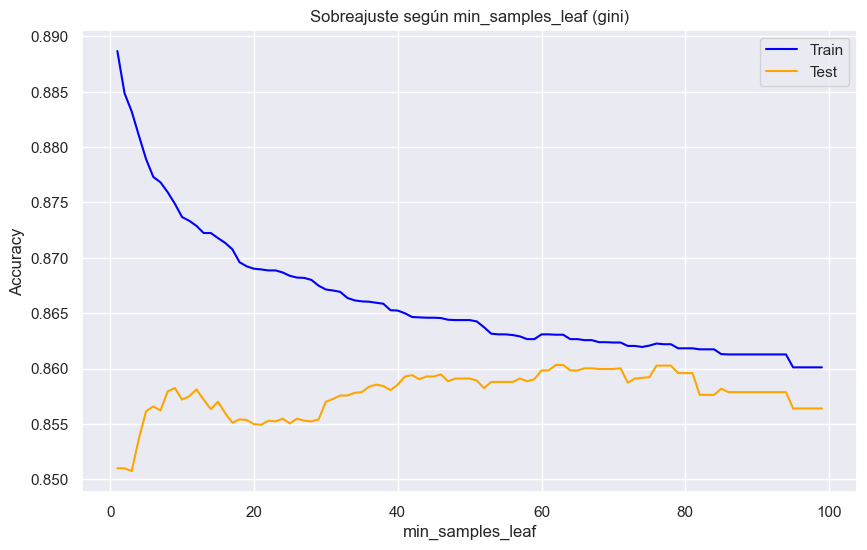

In [115]:
for c in criterios:
    precision=[]
    precision_test=[]
    for hojasVariable in range(1,100,1): #numHojas
        #print("Hojas",hojasVariable)
        p,p_t = experimento(df,df_test,c,13,hojasVariable) #Pongo 13 de profundidad pq en las gráficas parece un punto medio
        precision.append(p)
        precision_test.append(p_t)

    min_samples = list(range(1,100,1))

    plt.figure(figsize=(10,6))
    plt.plot(min_samples, precision, label="Train", color='blue')
    plt.plot(min_samples, precision_test, label="Test", color='orange')
    plt.xlabel("min_samples_leaf")
    plt.ylabel("Accuracy")
    plt.title(f"Sobreajuste según min_samples_leaf ({c})")
    plt.legend()
    plt.grid(True)
    plt.show()


Finalmente, la cantidad óptima que debe tener min_samples_leaf se encuentra en 8 con una profundidad de 10 para el criterio entropy, con un 86.2% de precisión.<br>
La cantidad óptima en gini, está en 13 hojas hojas, con un 86.25% de precisión

Teniendo en cuenta estos datos, la configuración que escogería para un buen clasificador sería usar los datos indicados en cada criterio. El criterio que mejor resultado ha tenido, ha sido gini.

--- 

# 4. Implementación de un árbol de clasificación

En este apartado, vamos a implementar un árbol de clasificación C4.5. Se proporciona un modelo básico capaz de tratar variables categóricas, realizando las divisiones por error simple, y sin poda. Hay que ampliar el modelo para que cuente con las siguientes características:
1. Utilizar el índice GINI para el cálculo del error.
2. Utilizar la entropía condicional para el cálculo del error.
3. Utilizar variables continuas en el entrenamiento y predicción.
4. Poda del árbol.

Para la estructura del código vamos a seguir la de los algoritmos de `scikit-learn`. Por tanto, nuestro modelo `C45Classifier` heredará de [`BaseEstimator`](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html), la clase base para todos los estimadores de `scikit-learn`, y de [`ClassifierMixin`](https://scikit-learn.org/stable/modules/generated/sklearn.base.ClassifierMixin.html), la clase base de los clasificadores. Además, debemos implementar los siguientes métodos principales: 

- `__init__()`: Constructor del modelo, recibirá los hiperparámetros necesarios.
- `fit(X,y)`: Método de entrenamiento del modelo. Recibe $X$ e $y$ y devuelve el modelo ya entrenado.
- `predict(X)`: Método de predicción del modelo. Recibe $X$ como un conjunto de instancias a predecir y devuelve $y_{pred}$, un vector de predicciones asociadas a $X$.

Por otro lado, está el siguiente método que, si bien es importante, al heredar de `ClassifierMixin` ya viene establecido por defecto a `accuracy_score`:
- `score(X,y)`: Método de evaluación del modelo. Recibe $X$ e $y$, predice $y_{pred}$ a partir de $X$, y devuelve el porcentaje de acierto de $y_{pred}$ respecto a $y$.

## 4.1 Clase `Node`
Antes de implementar la clase principal `C45Classifier`, vamos a crear una clase `Node` que codifique la información necesaria para cada uno de los nodos del árbol. Cuenta con las siguientes funciones:
- `__init__(self):` Constructor. En él inicializamos las variables necesarias, explicadas en los comentarios del código.
- `__str__(self):` Método que nos permite imprimir nuestros árboles.
- `predict(self,x):` Método que nos permitirá hacer predicciones recursivamente hasta llegar a un nodo hoja. Cuando el `Node` es hoja devuelve el valor de su clase, y si no, tendrá que llamar a la función `predict(x)` del hijo que corresponda. 

## **<font color="#B30033" size=6>TAREA: </font>** Método predict para variables continuas
El método `predict` actualmente se proporciona adaptado a la predicción de variables discretas. Deberéis ampliarlo para que funcione cuando la variable del nodo es continua.<br>

Aquí se explicará el desarrollo de la función predict desarrollada en Practica_1_2025.ipynb.<br>

La esencia del método predict es bajar desde el nodo raíz hasta una hoja. Consiste en "preguntar" constantemente hasta llegar a una conclusión final, que será si gana más o menos de 50K. Por cada pregunta, utilizando el árbol ya entrenado, se baja un nodo más y se repite hasta llegar a la decisión final, que es cuanto ganará.<br><br>

Para comprobar que funciona correctamente, comparamos las predicciones obtenidas en prediccionTrain y prediccionTest; calculamos el porcentaje de aciertos comparando la predicción obtenida con la real y analizamos los datos obtenidos.

In [116]:
import random

class Node:
    def __init__(self):
        # Indica si el nodo es una hoja, o no
        self.is_leaf = False

        # Atributos relacionados con la variable que representa el nodo
        self.is_num = True      # Indica si la variable es numérica (True) o categórica (False)
        self.cat_dict = None    # Diccionario para variables categóricas con formato {valor: indice}
        
        # Atributos cuando el objeto es una raíz
        self.var = None         # Nombre de la variable de corte
        self.var_index = -1     # Índice de la variable de corte
        self.cut_value = 0      # Valor de la variable de corte, en caso de ser numérica
        self.children = []      # Lista de hijos

        # Atributos cuando el objeto es una hoja
        self.class_value = -1       # Valor de la clase si el nodo es hoja
        self.class_count = (0,0)    # Tupla con el formato (casos con valor class_value, casos totales en la hoja)(numero de casos acertados, número de casos totales)

        # Profundidad del nodo
        self.depth = -1

    def __str__(self):
        output = ''
        if(self.is_leaf):
            output += 'Class value: ' + str(self.class_value) + '\tCounts: ' + str(self.class_count)
        else:
            output += 'Feature '+ str(self.var)
            for i in range(len(self.children)):
                output += '\n'+'\t'*(self.depth+1)+str(self.cut_value)+': '+str(self.children[i]) 
            
        return output
    
    # Esta función nos servirá para hacer predicciones recursivamente hasta llegar a un nodo hoja. Debe ser completada
    # Simplemente tiene que hacer las predicciones y devolverlas, los calculos de los distintos valores que hay que comprobar y devolver (cut_value, class_value,etc...) se realizan dentro del desarrollo del árbol
    def predict(self,x):
        if self.is_leaf:
            return self.class_value
        else:           
            value = x[self.var_index] # Buscamos la mejor categoría. Indica que columna mira nodo y extrae valor concreto de esa columna
            if self.is_num:
                if not isinstance(value, (int, float)): #para los numeros comprobamos si es entero o float, si no lo es devolvemos error
                    raise ValueError(f"Expected numeric for {self.var}, got {type(value)}: {value}") #¿Este error no es inalcanzable?
                if value <= self.cut_value: # devolvemos la mejor predicción dependiendo si es menos (nos vamos por el primero) o si es mayor (nos vamos por el segundo)
                    return self.children[0].predict(x)
                else:
                    return self.children[1].predict(x)
            else:
                if not isinstance(value, str): #para los discretos, comprobamos si es un string, si no lo es devolvemos errror
                    raise ValueError(f"Expected string for {self.var}, got {type(value)}: {value}")
                if value not in self.cat_dict: # Si el valor a buscar no aparece en el diccionario asignamos el primer hijo, si no cogemos el índice
                    child = 0 #Pillamos hijo 0 predeterminadamente si no está. Escogemos primera rama dicho nodo
                else:
                    child = self.cat_dict[value] #Hijo correcto según diccionario
                return self.children[child].predict(x) # devolvemos la predicción del hujo correcpondiente

Para comprobar que funciona correctamente, comparamos las predicciones obtenidas en prediccionTrain y prediccionTest; calculamos el porcentaje de aciertos comparando la predicción obtenida con la real y analizamos los datos obtenidos.

In [117]:
features = df.columns
attributes = features[:-1]
target = features[-1]
disc_atts = df.columns[df.dtypes == "object"].drop(target) # Antes iba, al día siguiente no...
cont_atts = df.columns[df.dtypes == "int64"].drop("fnlwgt")
X, y = df[attributes].to_numpy(), df[target].to_numpy()
X_test, y_test = df_test[attributes].to_numpy(), df_test[target].to_numpy()


# Entrena
arbol = C45Classifier(attributes, disc_atts, cont_atts, max_depth=10, criterion="gini", prune=True)
arbol.fit(X,y) #Lo entrenamos pq siempre lo entrenamos

prediccionTrain = arbol.predict(X) #Sacamos el vector de predicciones
prediccionTest = arbol.predict(X_test)

Porcentaje_Correcto_Train = 0
for predicciones in range(len(y)):
    if y[predicciones] == prediccionTrain[predicciones]: #Si el vector de aciertos es igual a como debe ser
        Porcentaje_Correcto_Train += 1
Porcentaje_Correcto_Train = Porcentaje_Correcto_Train/len(y)
print("Porcentaje predict en Train", Porcentaje_Correcto_Train)

Porcentaje_Correcto_Test = 0
for prediccionesTest in range(len(y_test)):
    if y_test[prediccionesTest] == prediccionTest[prediccionesTest]: #Si el vector de aciertos es igual a como debe ser
        Porcentaje_Correcto_Test += 1
Porcentaje_Correcto_Test = Porcentaje_Correcto_Test/len(y_test)
print("Porcentaje predict en test", Porcentaje_Correcto_Test)

No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo hoja
No soy nodo ho

## 4.2 Clase `C45Classifier`
Esta será la clase principal, que representará nuestro clasificador C4.5. Los argumentos que recibirá serán los siguientes:
* `vars`, `disc`, `cont`: 3 listas. Nombres de las variables con el mismo orden con el que aparecen en $X$, y de ellas, cuáles son discretas y cuales son continuas. No sería estrictamente necesario, pero simplificará bastante el desarrollo de la práctica.
* `max_depth`: Profundidad máxima del árbol. Si no se especifica, será 2.
* `criterion`: Criterio de partición. Puede tomar los valores `classification_error`, `entropy` y `gini`. Si no se especifica, será 'entropy'.
* `prune`: Booleano. Si es `True`, se podará el árbol. Si no se especifica, será `False`.


## **<font color="#B30033" size=6>TAREA: </font>** Implementación del índice GINI y la entropía condicional


## **<font color="#B30033" size=6>TAREA: </font>** Uso de variables continuas


## **<font color="#B30033" size=6>TAREA: </font>** Poda del árbol


In [118]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from collections import Counter

class C45Classifier(BaseEstimator, ClassifierMixin):

    # Constructor de la clase, aquí se definen e inicializan las variables de la clase.
    def __init__(self, vars, disc, cont, max_depth=2, criterion='classification_error', prune=False):
        self.max_depth = max_depth
        self.criterion = criterion
        self.prune = prune

        self.vars = vars
        self.disc = disc
        self.cont = cont

        # Diccionario que nos permitirá convertir el nombre de la variable en su índice.
        self.features_dict = {feat: i for i, feat in enumerate(self.vars)}

        # Raíz del árbol
        self.tree = Node()   


    # Función para entrenar el modelo.
    def fit(self, X, y):#Contruye árbol de decisión
        # Llamada a la función recursiva que aprende el árbol.
        self._partial_fit(X, y, self.tree, 0, set([]))

        if self.prune:
            self._prune_tree()
        
        return self
    

    # Función para hacer predicciones.
    def predict(self, X):#Usar árbol ya clasificado para clasificar nuevos datos
        return np.array([self.tree.predict(x) for x in X]) #Devuelve vector predicciones basado en tree. Usa el predict de arriba
    

    # Función recursiva que busca la variable y corte que maximiza la ganancia de información.
    # - Las variables continuas se tratan con un corte binario, lo que quiere decir que pueden ser usadas multiples veces. 
    # - Las variables discretas ramifican tantas veces como valores tengan, asi que solo pueden ser usadas una vez por camino, 
    #   debiendo almacenarlas en el conjunto `borradas`. 
    def _partial_fit(self, X, y, current_tree, current_depth, borradas):
        def _make_leaf(): #Convierte nodo en hoja
            current_tree.is_leaf = True
            counts = Counter(y)
            max_value = counts.most_common(1) # most_common(1) devuelve una lista con el elemento más común y su frecuencia.
            current_tree.class_value = max_value[0][0]#
            current_tree.class_count = (max_value[0][1], len(y)) #Casos de esa clase en esa hoja
            return
        
        # Antes de nada, si hemos alcanzado la profundidad máxima, el nodo se convierte en hoja.
        if current_depth >= self.max_depth:
            _make_leaf()
            return

        # Primero obtenemos el mejor punto de corte para el nodo actual dependiendo del criterio.
        best_var, cut_value, is_num = self._split(X, y, borradas, self.criterion) #Criterios son classification_error, entropy, gini
        #best_var es nombre variable con mejor corte
        #cut_value es valor partición

        # Si no hay ninguna partición que mejore la actual, el nodo se convierte en hoja.
        if best_var is None:
            _make_leaf()
            return
    
        # Antes de llamar a la función recursiva, hay que actualizar los valores del árbol.
        borradas_copy = borradas.copy()
        if not is_num:    # Solo borramos las variables categóricas ya que estarán totalmente particionadas.
            borradas_copy.add(best_var)
            current_tree.is_num = False

        current_tree.is_leaf = False
        current_tree.depth = current_depth
        current_tree.var = best_var
        current_tree.var_index = self.features_dict[best_var]

        # Finalmente, se hace la llamada recursiva en función de si es numérica o categórica.
        if is_num:
            nodoMayor=Node()  #Se crean los dos nodos y las particiones. Cumple <=cut_value
            nodoMenor=Node()
            izquierda,derecha = X[:,current_tree.var_index] <= cut_value, X[:,current_tree.var_index] > cut_value

            X_izq , y_izq = X[izquierda], y[izquierda] # Separamos las partes
            X_der , y_der = X[derecha], y[derecha]
            
            self._partial_fit(X_izq, y_izq, nodoMenor, current_depth + 1, borradas_copy) #Hacemos las llamadas para calcular los dos hijos
            self._partial_fit(X_der, y_der, nodoMayor, current_depth + 1, borradas_copy)

            current_tree.children = [nodoMayor, nodoMenor] #Guardamos los hijos
            current_tree.cut_value = cut_value
            current_tree.is_num = True
        else:
            ramificaciones = np.unique(X[:,current_tree.var_index]) #Coge toda columna dicha variable. Elimina repetidos y ordena
            i = 0
            cat_dict = {}
            for rama in ramificaciones:
                nodo = Node()
                dato = X[:, current_tree.var_index] == rama #Devuelve vector de  bool en función de si la persona en la q está operando, tiene dicha rama
                X_sub,y_sub = X[dato],y[dato] #Se quedan con filas y etiquetas donde son true

                self._partial_fit(X_sub,y_sub,nodo,current_depth + 1, borradas_copy)

                current_tree.children.append(nodo)
                cat_dict[rama] = i
                i+=1
            current_tree.cat_dict = cat_dict
            current_tree.is_num = False
            current_tree.cut_value = None
        return


    # Cálculo del mejor punto de corte en función de: Error de clasificación.
    #classification_error es el % datos clasifican incorrectamente
    def _split(self, X, y, borradas, criterion='classification_error'):
        # Error actual (sin partición)
        error_best = self._compute_split_criterion(y, criterion) #_compute_split_criterion mejor punto corte

        best_var = None
        is_num = True
        cut_value = None    # Para variables categóricas no hay valor de corte (devolvemos None).
        
        for var in self.vars:
            # Saltamos variables que ya fueron usadas (en discretas)
            if var in borradas:
                continue
                
            index = self.features_dict[var]
            
            if var in self.disc: #Hacemos una ramificación por cada opción.
                # Obtener valores únicos de la variable discreta
                ramificaciones = np.unique(X[:, index]) #Con esto saco todas ramificaciones
                
                #Calcular media todas ramas
                error = 0
                for val in ramificaciones: #X[:, index] extrae una columna
                    esta = X[:, index] == val #array de si está dicho dato
                    y_subset = y[esta] #Todos los verdaderos por rama
                    #Error para este subset
                    error_subset = self._compute_split_criterion(y_subset, criterion)
                    #Peso es la proporción de ejemplos en este subset
                    peso = len(y_subset) / len(y) #Divido el la rama entre todos los q hay
                    error += peso * error_subset
                
                # Comparar con el mejor error encontrado hasta ahora
                if error < error_best: #Es mejor
                    error_best = error
                    best_var = var
                    is_num = False
                    cut_value = None
                    #borradas.add(var)

            elif var in self.cont:
                valores = np.unique(X[:, index]) #como arriba

                if len(valores) > 1: # Si hay suficientes valores, probamos puntos de corte entre ellos
                    for i in range(len(valores) - 1):
                        umbral = (valores[i] + valores[i+1]) / 2 #media presente y siguiente
                        
                        #Partición izquierda. los q tienen <= umbral
                        left_mask = X[:, index] <= umbral
                        y_left = y[left_mask]
                        
                        #Partición derecha
                        right_mask = X[:, index] > umbral
                        y_right = y[right_mask]
                        
                        if len(y_left) > 0 and len(y_right) > 0: #No casos vacios
                            error_left = self._compute_split_criterion(y_left, criterion)
                            error_right = self._compute_split_criterion(y_right, criterion)
                            
                            weight_left = len(y_left) / len(y) #Proporcionalmente como arriba
                            weight_right = len(y_right) / len(y)
                            
                            error = weight_left * error_left + weight_right * error_right
                            
                            if error < error_best: #Guardar si si
                                error_best = error
                                best_var = var
                                is_num = True
                                cut_value = umbral
                                best_ramificaciones = None

            # Si conseguimos un error de 0 (óptimo), terminamos
            if error_best == 0:
                break

        if best_var in self.disc:
            borradas.add(best_var)
        return best_var, cut_value, is_num

    # Cálculo del mejor punto de corte en función de: Error de clasificación; Entropía; Índice Gini.
    def _compute_split_criterion(self, y, criterion='classification_error'):
        # Completar aquí si tenéis código común a los tres criterios.
        ramas,contaRamas = np.unique(y, return_counts=True) #Devuelve [A,B,c] y [1,5,2] por ejemplo
  
        if criterion == 'classification_error': #Apuesto a la clase q más se repite
            # indice = contaRamas.index(max(contaRamas)) #Saca el indice del numero max
            return 1 - (max(contaRamas)/sum(contaRamas)) #Sigue la fórmula
        elif criterion == 'entropy': #H(S) = −SUM(ci=1pilog2(pi))
            return - sum( contaRamas/sum(contaRamas) * np.log2(contaRamas/sum(contaRamas) ) ) #Como en clase sacábamos
                                                                            #cuanto % era
        elif criterion == 'gini':
            return 1 - sum((contaRamas/sum(contaRamas))**2) #Creo q es así x los paréntesis t tal
        else:
            raise ValueError('Criterio no válido.')

    
    # TODO: Completar esta función para realizar la poda del modelo.
    def _prune_tree(self): 
        self.k=2 #Número de clases. En este caso <=50K y >50K
        if self.tree:
            self.prune_recursive(self.tree)
    
    def laplace(self,N,n): #N es número total de ejemplos del nodo y n son los bien clasificados
        if N == 0:
            return 0
        else:
            return (N-n + self.k-1)/(N+self.k)
    
    def prune_recursive(self,nodo):
        #Si es hoja devolvemos su error y su valor
        if nodo.is_leaf:
            n,N = nodo.class_count
            return nodo.is_leaf,self.laplace(N,n), nodo.class_count, nodo.class_value
        
        else: #Si tiene hijo hacemos llamada recursiva
            #print("No soy nodo hoja")
            children = nodo.children if nodo.is_num else list(nodo.cat_dict.values())
            poda = True
            child_errors=[]
            N_children=[]
            dict_clases = {"<=50K":0, ">50K":0}
            if nodo.is_num: #Si es numérica podemos acceder a los hijos directamente
                for child in children:
                    is_leaf,child_error,(n_child,N_child),value=self.prune_recursive(child)
                    if not is_leaf: 
                        poda = False
                    child_errors.append(child_error)
                    N_children.append(N_child)
                    if value != -1:
                        dict_clases[value]+=n_child
            else: # Si es categórica accedemos a una lista de los índices de una lista (muy parecido a lo implementado en las numéricas)
                for index in children:
                    child = nodo.children[index]
                    is_leaf,child_error,(n_child,N_child),value=self.prune_recursive(child)
                    if not is_leaf: 
                        poda = False
                    child_errors.append(child_error)
                    N_children.append(N_child)
                    if value != -1:
                        dict_clases[value]+=n_child
            
            N_padre = sum(N_children)
            n_padre = max(dict_clases.values())
            child_errorssum=0
            if N_padre > 0:
                for i in range(child_errors.__len__()):
                    child_errorssum += (N_children[i]/N_padre) * child_errors[i]

            error_padre = self.laplace(N_padre,n_padre)
            
            if error_padre <= child_errorssum and poda:
                nodo.is_leaf = True
                nodo.class_value = max(dict_clases, key = dict_clases.get)
                nodo.class_count = (n_padre,N_padre)
                return True,error_padre,nodo.class_count,nodo.class_value
            else:
                return False,error_padre, nodo.class_count, nodo.class_value

    # Función para imprimir el modelo.
    def __str__(self):
        return str(self.tree)


## **<font color="#B30033" size=6>Método _partial_fit</font>** <br>

la función <code>_partial_fit</code>, busca la variable y corte que maximiza la ganancia de información. Esto quiere decir que hace varias preguntas con varios resultados. Se queda con la que mejor separa las clases. Está maximizando la ganancia de información, reduciendo la mezcla de clases en sus hijos, de esta forma, reduciendo el error.<br>

Con la función <code>split</code>, de la que posteriormente hablaremos, sacamos la mejor variable para dividir en best_var(age o workclass, por ejemplo), el valor de corte si es continua con <code>cut_value</code> y si es numérica o no con <code>is_num</code>. Si ya tenemos la mejor variable con best_var=none, entonces convertimos dicho nodo en hoja.<br>

Ahora hablaremos de los procedimientos que hemos implementado, haciendo la llamada recursiva en función de si es numérica o categórica.<br>
Cuando la variable es numérica, se crean dos caminos por que la variable es numérica. Los que están por encima y por debajo del punto de corte. Posteriormente, sacamos los hijos de estos dos árboles recursivamente. Para finalizar, guardamos los valores.<br>

Cuando las variables son discretas, primero sacamos todas las ramificaciones y se tendrá un hijo por cada rama de dicha variable. Obtenemos un vector de bools que nos dice si la persona en la que se está iterando, tiene dicha rama de la ramificación. Con estos datos, volvemos a llamar recursivamente.


## **<font color="#B30033" size=6>Método _Split</font>**  <br>

Este método se encarga de buscar el mejor punto de corte en función del error de clasificación.<br>

En este método, de la misma forma que en el anterior, dividimos si es una variable continua o discreta. <br>

Si la variable es discreta, de la misma forma que en la anterior función, saco las ramificaciones y compruebo cuantas veces se repite cada característica. Saco los pesos de cada característica y con la función <code>_compute_split_criterion</code> se calcula el error en cada ramificación. Finalmente, comparamos con el anterior mejor.<br>

cuando la variable sea continua, primero saco los valores distintos de esa columnas. Pruebo los distintos puntos de corte entre valores consecutivos. El umbral es la media entre el que itera actualmente y el siguiente. Divido con el criterio de los que están por encima y por debajo del umbral. Si ambas particiones tienen datos, saco su error con <code>_compute_split_criterion</code> y sus pesos.



## **<font color="#B30033" size=6>Método _compute_split_criterion</font>**  <br>

El método <code>_compute_split_criterion</code> calcula la impureza de un conjunto de datos a partir de sus etiquetas, siendo clave para decidir las mejores particiones en el árbol C4.5. Primero obtiene las frecuencias de cada clase y sus probabilidades. A partir de ellas, implementa tres criterios: error de clasificación (1 − max(pi)), este sería apostar todo a la clase más común. Entropía (−∑ pi log2(pi)). Este mide el caos, si está mezclado 50/50, la entropía es máxima. Finalmente, Gini (1 − ∑ pi²), midiendo la posibilidad de clasificar mal un elemento. En todos los casos, valores cercanos a 0 indican mayor pureza del nodo. Este cálculo se utiliza en el método <code>split</code> para seleccionar la división óptima.



## **<font color="#B30033" size=6>Método _prune_tree</font>**  <br>

Esta función es la encargada de podar el árbol. Sirve para evitar que el árbol se aprenda los datos de memoria, de forma que si un hijo no aporta una mejora real, se corta y el padre se convierte en un nodo hoja. Para desarrollarla, hemos tenido que dividirla en dos funciones más. En total usamos: _prune_tree, laplace y prune_recursive.<br>

&nbsp; &nbsp; &nbsp; •_prune_tree:Comprueba si el propio objeto es un árbol y si se dá el caso, entonces llama a la función prune_recursive<br>

&nbsp; &nbsp; &nbsp; •laplace: Calcula una estimación suavizada del error con la siguiente fórmula: (N-n + self.k-1)/(N+self.k) <br>

&nbsp; &nbsp; &nbsp; •prune_recursive: Recorre el árbol de forma recursiva de abajo hacia arriba una vez ya está hecho el árbol. Calcula el error de cada hijo y el del padre. Si el padre tiene menor error, entonces se poda el hijo y el padre pasa a ser una nueva hoja. Llama recursivamente a este procedimiento hasta que no se pode en ninguna hoja.

--- 

# 5. Pruebas y estudio del algoritmo implementado

Finalmente, se deberán realizar pruebas con el clasificador para verificar su funcionamiento. A continuación, se incluyen algunos ejemplos de ejecución. Podéis incluir estos ejemplos en vuestra entrega, pero deberéis añadir más para demostrar que todas las partes de la práctica funcionan correctamente (variables continuas/discretas; error de clasificación/entropía/gini; con poda/sin poda, etc.). Además, se deberá razonar por qué los resultados son distintos de un caso a otro. 

Este apartado es más "libre", por lo que podéis hacer todas las pruebas y comparaciones que consideréis relevantes. Por ejemplo, podéis comparar vuestro algoritmo con los valores obtenidos por los árboles de `scikit-learn`, medir tiempos de ejecución... Además, si habéis incluido alguna característica opcional o distintiva de vuestro algoritmo, también debéis explicarla en este apartado.


### IMPORTANTE

**Se deberá mantener la eficiencia del clasificador. Esto significa que el tiempo de entrenamiento del árbol utilizando variables discretas o ambos tipos de variables debe ser similar. Obviamente, será mayor al incluir variables continuas en comparación con entrenar solo con las discretas (ya que solo se pueden particionar una vez), pero debe mantenerse dentro de un orden de magnitud similar.**

### Variables discretas, profundidad máxima 3, criterion='classification_error', sin poda

In [136]:
arbol = C45Classifier(attributes, disc_atts, [], max_depth=3, criterion='classification_error', prune=True)
arbol.fit(X,y)



C45Classifier(cont=[],
              disc=Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'),
              max_depth=3, prune=True,
              vars=Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object'))

In [120]:
print("Error en train: ", arbol.score(X,y))
print("Error en test: ", arbol.score(X_test,y_test))

Error en train:  0.7822855563404072
Error en test:  0.7839813279282599


### Variables discretas, profundidad máxima 10, criterion='classification_error', sin poda

In [160]:
# Al no estar implementado todavía el tratamiento de variables continuas, da igual que se especifiquen o no.
arbol = C45Classifier(attributes, disc_atts, [], max_depth=10, criterion='classification_error', prune=False)
arbol.fit(X,y)

C45Classifier(cont=[],
              disc=Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'),
              max_depth=10,
              vars=Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object'))

In [122]:
print("Error en train: ", arbol.score(X,y))
print("Error en test:  ", arbol.score(X_test,y_test))

Error en train:  0.7823162679278892
Error en test:   0.7839199066396413


### Variables discretas y continuas, profundidad máxima 2, criterion='classification_error', sin poda

In [123]:
# Al no estar implementado todavía el tratamiento de variables continuas, da igual que se especifiquen o no.
arbol = C45Classifier(attributes, disc_atts, cont_atts, max_depth=2, criterion='classification_error', prune=True)
arbol.fit(X,y) 

C45Classifier(cont=Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object'),
              disc=Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'),
              prune=True,
              vars=Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object'))

In [124]:
print("Error en train: ", arbol.score(X,y))


print("Error en test:  ", arbol.score(X_test,y_test))

Error en train:  0.7288166825343202
Error en test:   0.7306676494072846


In [ ]:
errorTrain=[]
errorTest =[]
tiempos = []
criterios=['classification_error','gini','entropy']

for poda in [True, False]:
    for c in criterios:
        for profunds in range(0,21,3):
            inicio = t.time()


            arbolExp = C45Classifier(attributes, disc_atts, cont_atts, max_depth=profunds, criterion=c, prune=poda)
            arbolExp.fit(X,y) 
            print("Árbol realizado con profundidad ", profunds, "criterio ", c, "y poda =",poda)

            errorTrain.append(1 - arbolExp.score(X,y))
            errorTest.append(1 - arbolExp.score(X_test,y_test))

            tiempos.append(t.time() - inicio)



    

Árbol realizado con profundidad  0 criterio  classification_error y poda = True


ValueError: Found input variables with inconsistent numbers of samples: [1, 32561]

ValueError: x and y must have same first dimension, but have shapes (7,) and (1,)

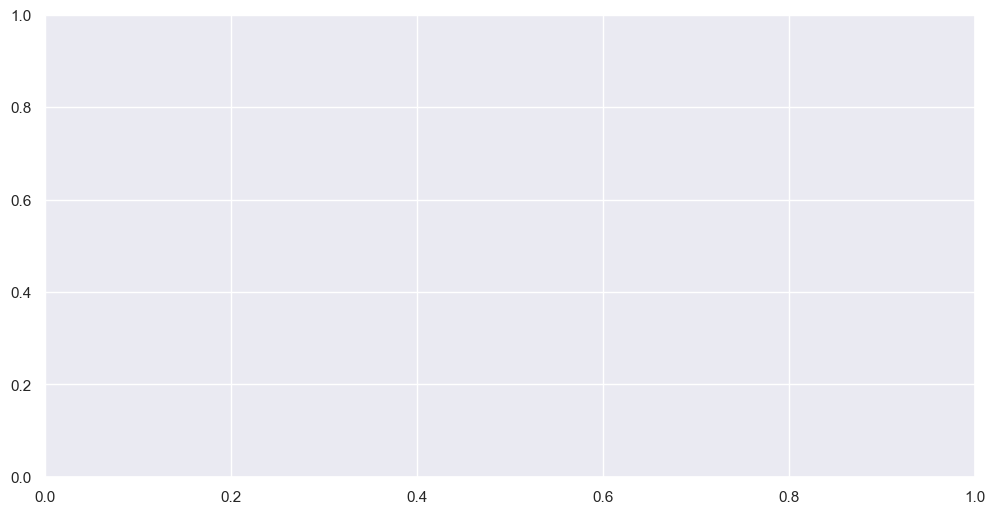

In [177]:
# SOLO GRAFICO (sin tocar tu código anterior)
# Reutiliza: tiempos, criterios y el rango de profundidades que ya usaste

import numpy as np
import matplotlib.pyplot as plt

podas = [True, False]
profundidades = list(range(0, 21, 3))

# Reconstruir tiempos_criterio desde la lista tiempos ya calculada
n_prof = len(profundidades)
tiempos_criterio = {c: [[], []] for c in criterios}  # [0]=poda True, [1]=poda False

idx = 0
for i_poda, _ in enumerate(podas):
    for c in criterios:
        tiempos_criterio[c][i_poda] = tiempos[idx:idx + n_prof]
        idx += n_prof

estilo_poda = {True: '-', False: '--'}  # interlineado por poda

# Criterios en rojo, verde y azul
color_base = {
    'classification_error': np.array([1.0, 0.0, 0.0]),  # rojo
    'gini': np.array([0.0, 1.0, 0.0]),                  # verde
    'entropy': np.array([0.0, 0.0, 1.0])                # azul
}

# Intensidad por profundidad
dmin, dmax = min(profundidades), max(profundidades)
def intensidad(d):
    if dmax == dmin:
        return 1.0
    return 0.25 + 0.75 * ((d - dmin) / (dmax - dmin))

plt.figure(figsize=(12, 6))

for c in criterios:
    for i, poda in enumerate(podas):
        y = tiempos_criterio[c][i]

        color_linea = tuple(color_base[c] * 0.65)
        plt.plot(
            profundidades, y,
            linestyle=estilo_poda[poda],
            color=color_linea,
            linewidth=2,
            label=f"{c} | poda={poda}"
        )

        colores_puntos = [tuple(color_base[c] * intensidad(d)) for d in profundidades]
        plt.scatter(profundidades, y, c=colores_puntos, s=55, edgecolor='black', linewidth=0.3)

plt.xlabel("max_depth")
plt.ylabel("Tiempo (s)")
plt.title("Tiempos vs max_depth (color=criterio, línea=poda, intensidad=profundidad)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()